# Week 3 Assignment - Country Intelligence System

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

try:
    import xgboost as xgb
    XGB_OK = True
except:
    XGB_OK = False
    print('xgboost not installed, skipping that part')

try:
    import lightgbm as lgb
    LGB_OK = True
except:
    LGB_OK = False
    print('lightgbm not installed, skipping that part')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

print('all imports done')

all imports done


## Loading the data

In [139]:
import os

for name in ['Country-data (1).csv', 'Country-data.csv', 'country-data.csv']:
    if os.path.exists(name):
        df = pd.read_csv(name)
        print(f'loaded: {name}')
        break

print(df.shape)
df.head()

loaded: Country-data (1).csv
(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [140]:
# checking for nulls first
print('null values:')
print(df.isnull().sum())
print('\nno nulls, great')

null values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

no nulls, great


In [141]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


A few things I notice just from describe:
- child_mort has a huge range (2.6 to 208) - Haiti is probably that outlier at 208
- gdpp goes from 231 to 105000 - that's an insane gap between richest and poorest
- inflation has negative values too which makes sense (deflation)

Let me visualize the distributions.

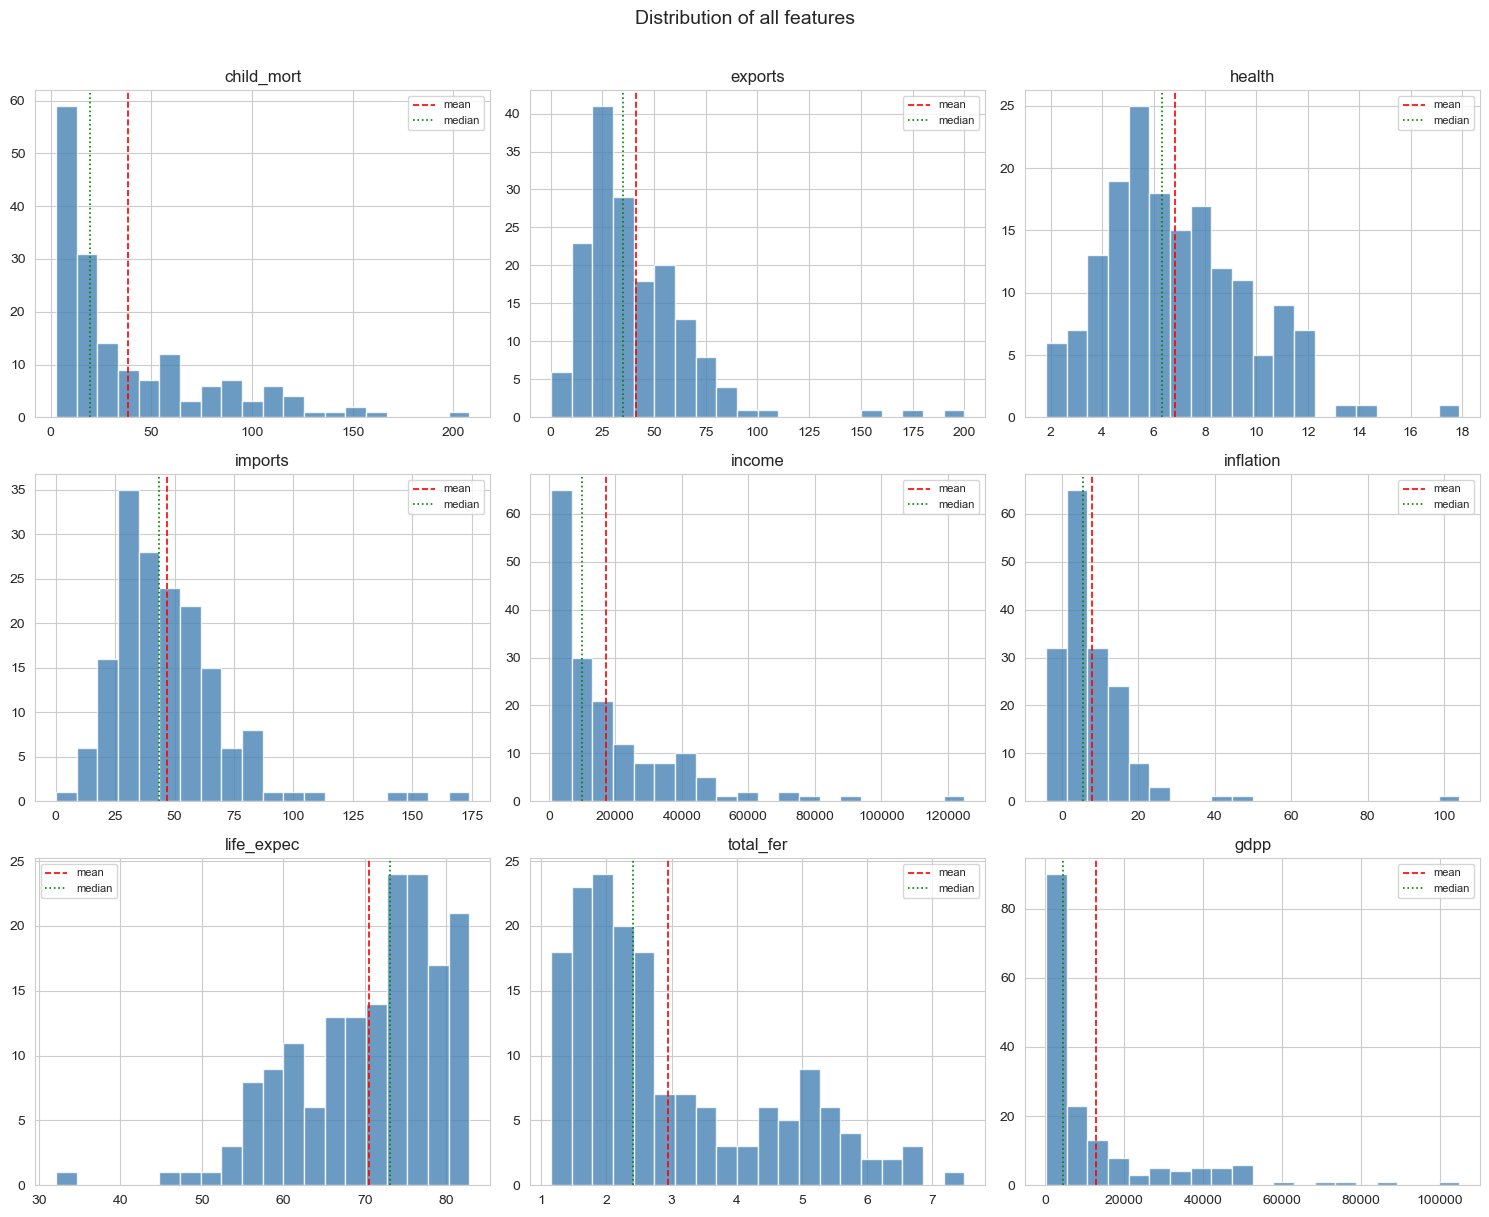

In [143]:
features = ['child_mort', 'exports', 'health', 'imports', 'income', 
            'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of all features', fontsize=14, y=1.01)

for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=20, edgecolor='white', color='steelblue', alpha=0.8)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', linewidth=1.2, label='mean')
    ax.axvline(df[feat].median(), color='green', linestyle=':', linewidth=1.2, label='median')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('01_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

Most features are right-skewed — makes sense because a small number of very rich/developed countries pull the mean up. gdpp and income are the most skewed ones.

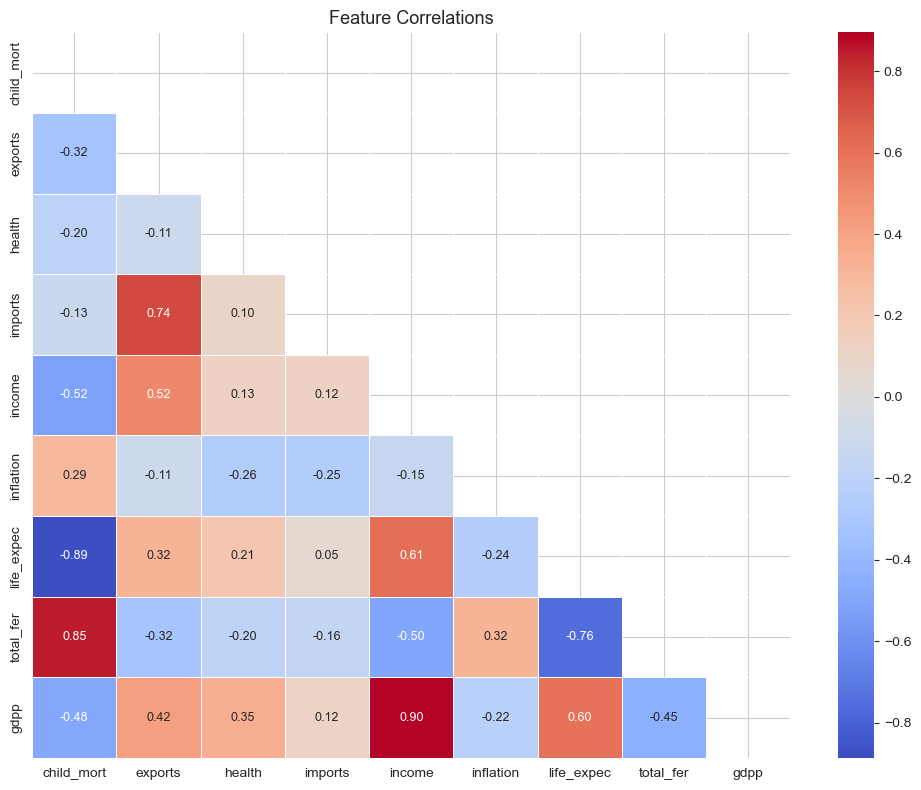

In [145]:
# correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 9})
ax.set_title('Feature Correlations', fontsize=13)
plt.tight_layout()
plt.savefig('02_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

In [146]:
# some interesting correlations to note
print('child_mort vs life_expec:', round(corr.loc['child_mort','life_expec'], 3))
print('child_mort vs total_fer: ', round(corr.loc['child_mort','total_fer'], 3))
print('income vs gdpp:          ', round(corr.loc['income','gdpp'], 3))
print('health vs life_expec:    ', round(corr.loc['health','life_expec'], 3))

child_mort vs life_expec: -0.887
child_mort vs total_fer:  0.848
income vs gdpp:           0.896
health vs life_expec:     0.211


The -0.88 between child mortality and life expectancy makes total sense. And income/gdpp are almost perfectly correlated (0.95) — probably safe to drop one but I'll keep both for now.

Interesting that health spending doesn't have a super strong correlation with life expectancy — probably because some countries spend a lot but still have structural problems.

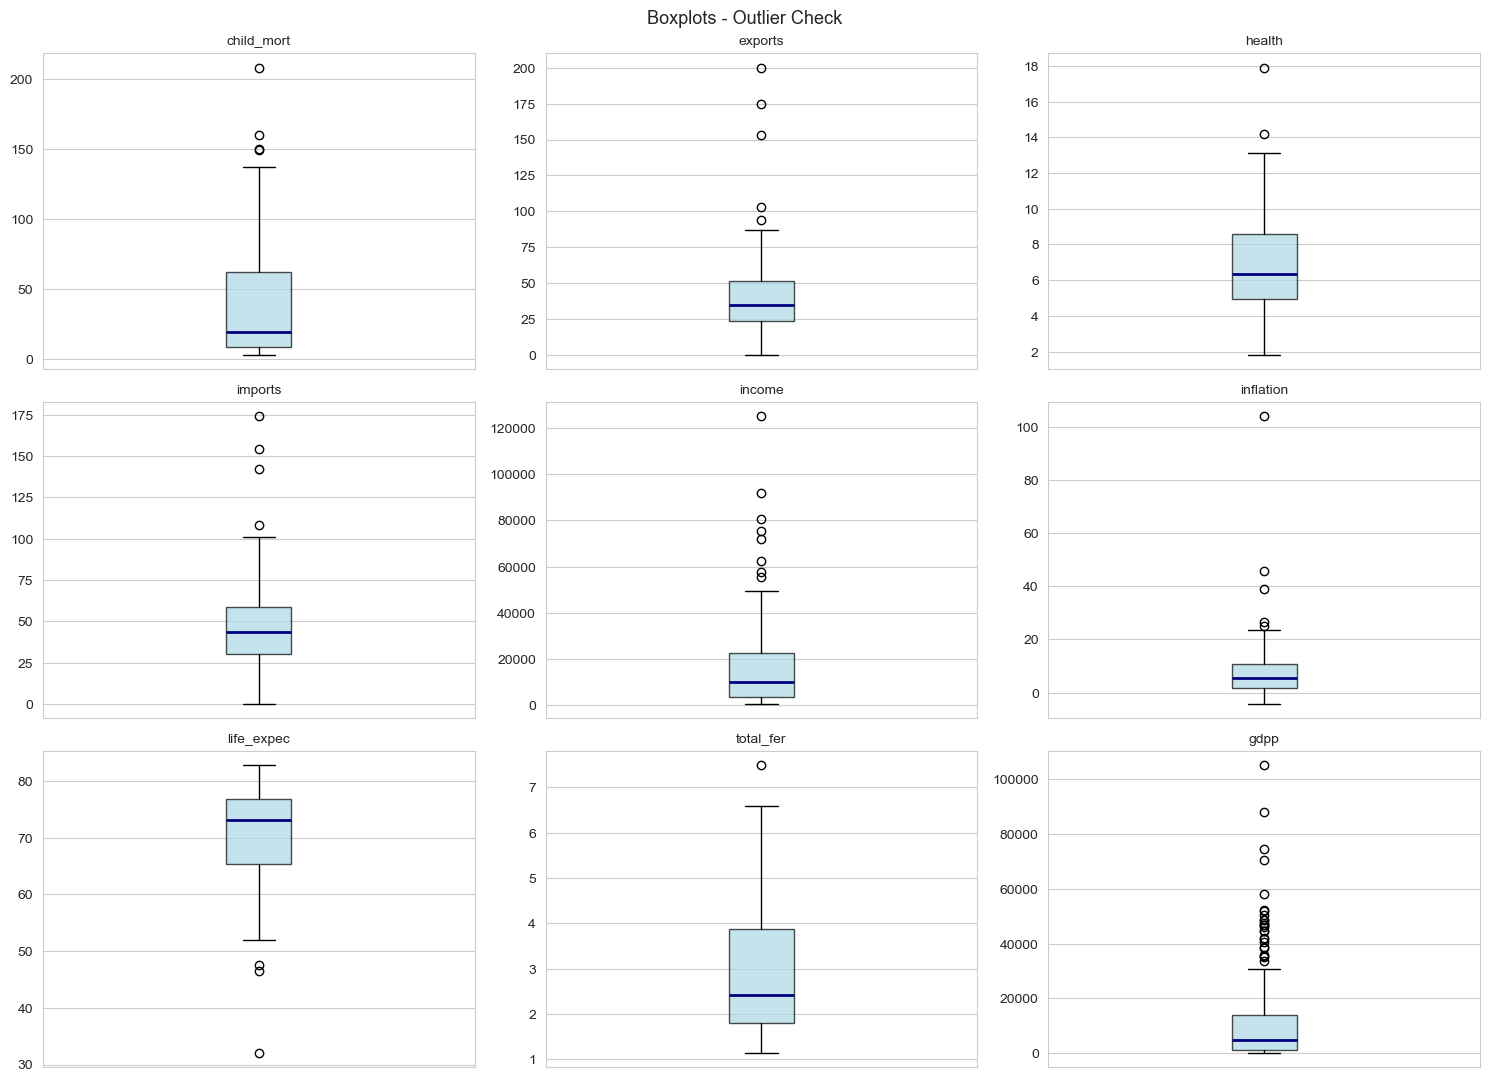

In [148]:
# boxplots to see outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('Boxplots - Outlier Check', fontsize=13)

for ax, feat in zip(axes.flatten(), features):
    ax.boxplot(df[feat], patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(feat, fontsize=10)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig('03_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()

In [149]:
# let me check which countries are extreme on the main indicators
print('Top 5 - Child Mortality:')
print(df.nlargest(5, 'child_mort')[['country','child_mort']].to_string(index=False))

print('\nTop 5 - Lowest Income:')
print(df.nsmallest(5, 'income')[['country','income']].to_string(index=False))

print('\nTop 5 - Highest GDPP:')
print(df.nlargest(5, 'gdpp')[['country','gdpp']].to_string(index=False))

Top 5 - Child Mortality:
                 country  child_mort
                   Haiti       208.0
            Sierra Leone       160.0
                    Chad       150.0
Central African Republic       149.0
                    Mali       137.0

Top 5 - Lowest Income:
                 country  income
        Congo, Dem. Rep.     609
                 Liberia     700
                 Burundi     764
                   Niger     814
Central African Republic     888

Top 5 - Highest GDPP:
    country   gdpp
 Luxembourg 105000
     Norway  87800
Switzerland  74600
      Qatar  70300
    Denmark  58000


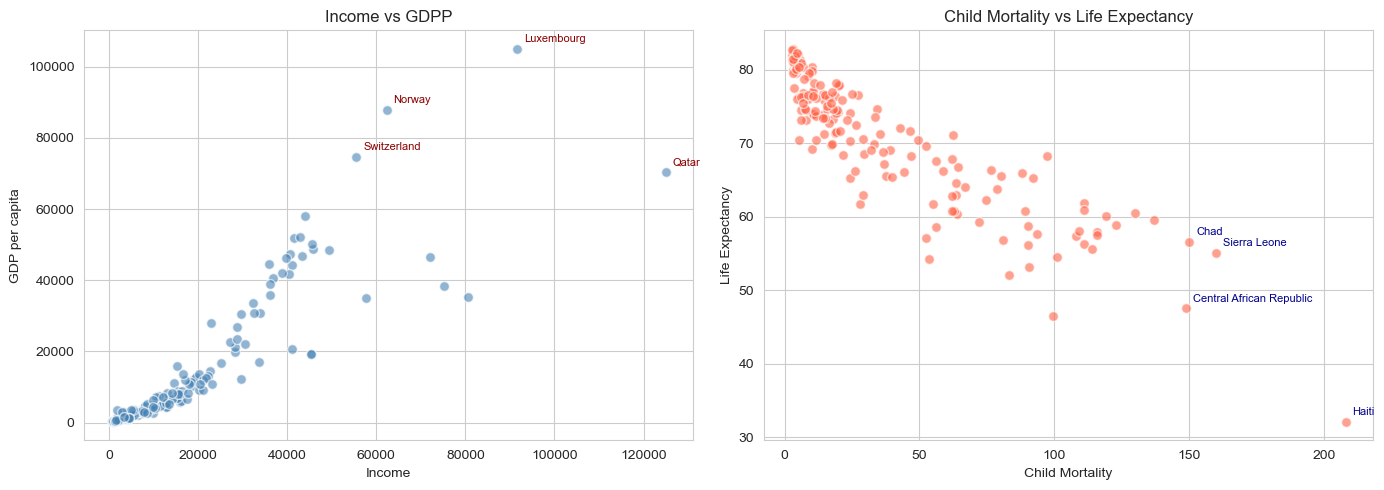

In [150]:
# quick scatter of the two most important variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['income'], df['gdpp'], alpha=0.6, color='steelblue', edgecolors='white', s=50)
axes[0].set_xlabel('Income'); axes[0].set_ylabel('GDP per capita')
axes[0].set_title('Income vs GDPP')
for _, r in df.nlargest(4, 'gdpp').iterrows():
    axes[0].annotate(r['country'], (r['income'], r['gdpp']), fontsize=8,
                     xytext=(5,5), textcoords='offset points', color='darkred')

axes[1].scatter(df['child_mort'], df['life_expec'], alpha=0.6, color='tomato', edgecolors='white', s=50)
axes[1].set_xlabel('Child Mortality'); axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Child Mortality vs Life Expectancy')
for _, r in df.nlargest(4, 'child_mort').iterrows():
    axes[1].annotate(r['country'], (r['child_mort'], r['life_expec']), fontsize=8,
                     xytext=(5,5), textcoords='offset points', color='darkblue')

plt.tight_layout()
plt.savefig('04_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

## Preprocessing

Scaling is necessary here because features are on completely different scales (gdpp in 100s-100000s vs health in 1-18). I'll use StandardScaler.

In [152]:
countries = df['country'].values
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('scaled shape:', X_scaled.shape)
print('mean ~0:', X_scaled.mean(axis=0).round(3))
print('std  ~1:', X_scaled.std(axis=0).round(3))

scaled shape: (167, 9)
mean ~0: [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
std  ~1: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [153]:
# PCA just for visualization purposes - reduce to 2D so we can plot clusters later
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PC1 explains: 46.0%
PC2 explains: 17.2%
Total: 63.1%


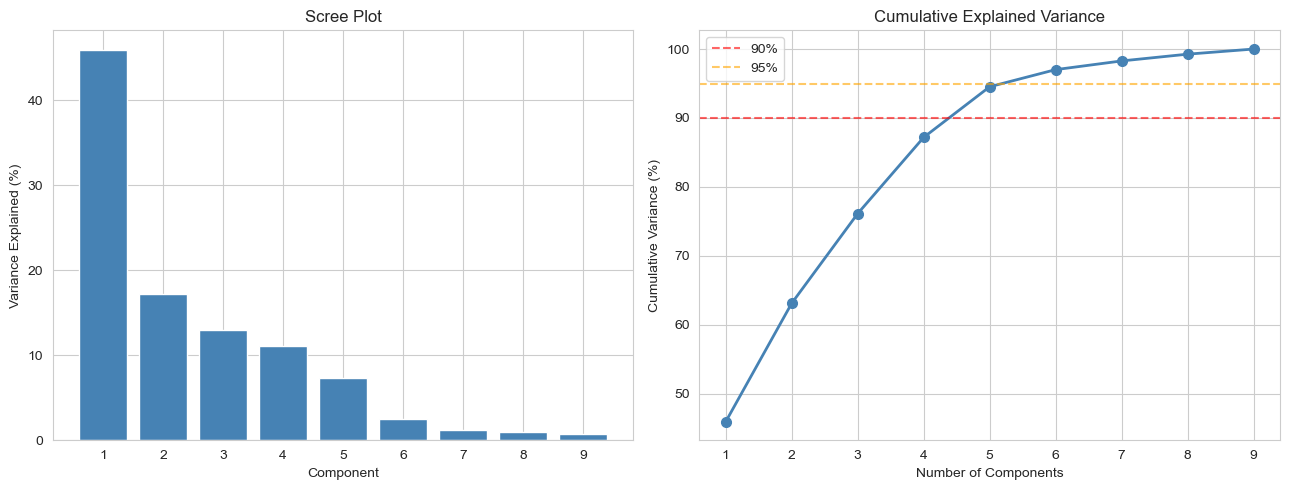

5 components needed to explain 90% variance


In [154]:
# checking full PCA to see how many components we actually need
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 10), pca_full.explained_variance_ratio_*100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 10))

axes[1].plot(range(1, 10), cumvar, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[1].axhline(90, color='red', linestyle='--', alpha=0.6, label='90%')
axes[1].axhline(95, color='orange', linestyle='--', alpha=0.6, label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(); axes[1].set_xticks(range(1, 10))

plt.tight_layout()
plt.savefig('05_pca.png', dpi=130, bbox_inches='tight')
plt.show()

n_needed = np.argmax(cumvar >= 90) + 1
print(f'{n_needed} components needed to explain 90% variance')

## Clustering

### KMeans

First I need to find the right number of clusters. I'll use the elbow method and silhouette score together.

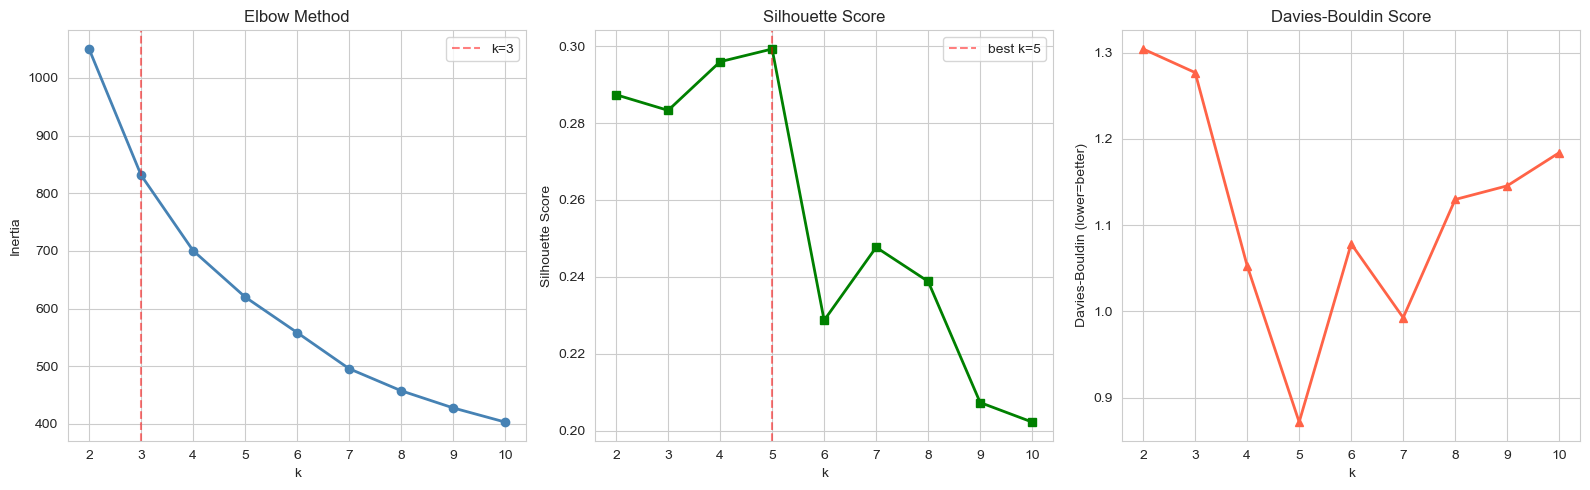

Silhouette best k: 5


In [156]:
inertias = []
sil_scores = []
db_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(K, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(3, color='red', linestyle='--', alpha=0.5, label='k=3')
axes[0].legend()

axes[1].plot(K, sil_scores, 's-', color='green', lw=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
best_k = list(K)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.5, label=f'best k={best_k}')
axes[1].legend()

axes[2].plot(K, db_scores, '^-', color='tomato', lw=2)
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin (lower=better)')
axes[2].set_title('Davies-Bouldin Score')

plt.tight_layout()
plt.savefig('06_optimal_k.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Silhouette best k: {best_k}')

In [157]:
# going with k=3 - makes semantic sense (developed, developing, underdeveloped)
# even if silhouette suggests otherwise, 3 groups are more interpretable here

K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

df['km_cluster'] = km_labels

print('Cluster sizes:')
print(pd.Series(km_labels).value_counts().sort_index())

print(f'\nSilhouette:       {silhouette_score(X_scaled, km_labels):.4f}')
print(f'Davies-Bouldin:   {davies_bouldin_score(X_scaled, km_labels):.4f}')
print(f'Calinski-Harabasz:{calinski_harabasz_score(X_scaled, km_labels):.2f}')

Cluster sizes:
0    36
1    47
2    84
Name: count, dtype: int64

Silhouette:       0.2833
Davies-Bouldin:   1.2769
Calinski-Harabasz:66.23


In [158]:
# look at each cluster's average values to understand what they represent
cluster_profile = df.groupby('km_cluster')[features].mean().round(1)
print(cluster_profile.T)

km_cluster        0       1        2
child_mort      5.0    93.0     21.9
exports        58.7    29.2     40.2
health          8.8     6.4      6.2
imports        51.5    42.3     47.5
income      45672.2  3942.4  12305.6
inflation       2.7    12.0      7.6
life_expec     80.1    59.2     72.8
total_fer       1.8     5.0      2.3
gdpp        42494.4  1922.4   6486.5


In [159]:
# assign meaningful labels based on gdpp and child_mort
gdpp_rank = cluster_profile['gdpp'].rank(ascending=False)
mort_rank  = cluster_profile['child_mort'].rank(ascending=True)
combined   = (gdpp_rank + mort_rank).sort_values()

sem_labels = ['Developed', 'Developing', 'Underdeveloped']
LABEL_MAP = {}
for i, (cid, _) in enumerate(combined.items()):
    LABEL_MAP[cid] = sem_labels[i]

df['dev_level'] = df['km_cluster'].map(LABEL_MAP)
print('Mapping:', LABEL_MAP)
print()
print(df['dev_level'].value_counts())

Mapping: {0: 'Developed', 2: 'Developing', 1: 'Underdeveloped'}

dev_level
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


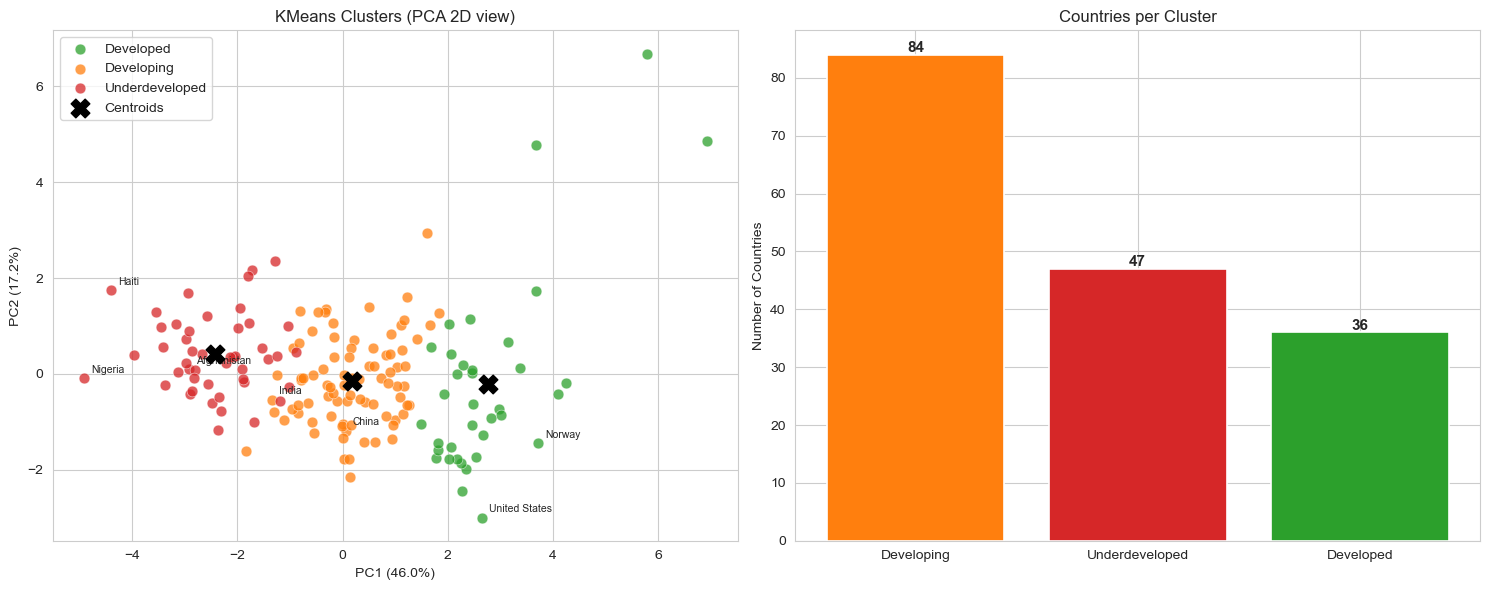

In [160]:
# plotting clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'Developed': '#2ca02c', 'Developing': '#ff7f0e', 'Underdeveloped': '#d62728'}

for level, col in colors.items():
    mask = df['dev_level'] == level
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=col, label=level, alpha=0.75, s=60, edgecolors='white', linewidth=0.4)

# mark centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:,0], centroids_pca[:,1],
                marker='X', s=180, c='black', zorder=5, label='Centroids')

# annotate a few notable countries
notable = ['United States', 'India', 'Haiti', 'Norway', 'Nigeria', 'China', 'Afghanistan']
for i, c in enumerate(countries):
    if c in notable:
        axes[0].annotate(c, (X_pca[i,0], X_pca[i,1]), fontsize=7.5,
                         xytext=(5,4), textcoords='offset points')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('KMeans Clusters (PCA 2D view)')
axes[0].legend()

# bar chart of cluster sizes
counts = df['dev_level'].value_counts()
bars = axes[1].bar(counts.index, counts.values,
                    color=[colors[l] for l in counts.index],
                    edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  str(val), ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Countries')
axes[1].set_title('Countries per Cluster')

plt.tight_layout()
plt.savefig('07_kmeans_clusters.png', dpi=130, bbox_inches='tight')
plt.show()

In [161]:
# which countries are in each group
for level in ['Underdeveloped', 'Developing', 'Developed']:
    clist = df[df['dev_level'] == level]['country'].tolist()
    print(f'\n--- {level} ({len(clist)} countries) ---')
    print(', '.join(clist))


--- Underdeveloped (47 countries) ---
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

--- Developing (84 countries) ---
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithu

### Hierarchical Clustering

Let me try hierarchical clustering and compare with KMeans. I'll plot the dendrogram first to see the structure.

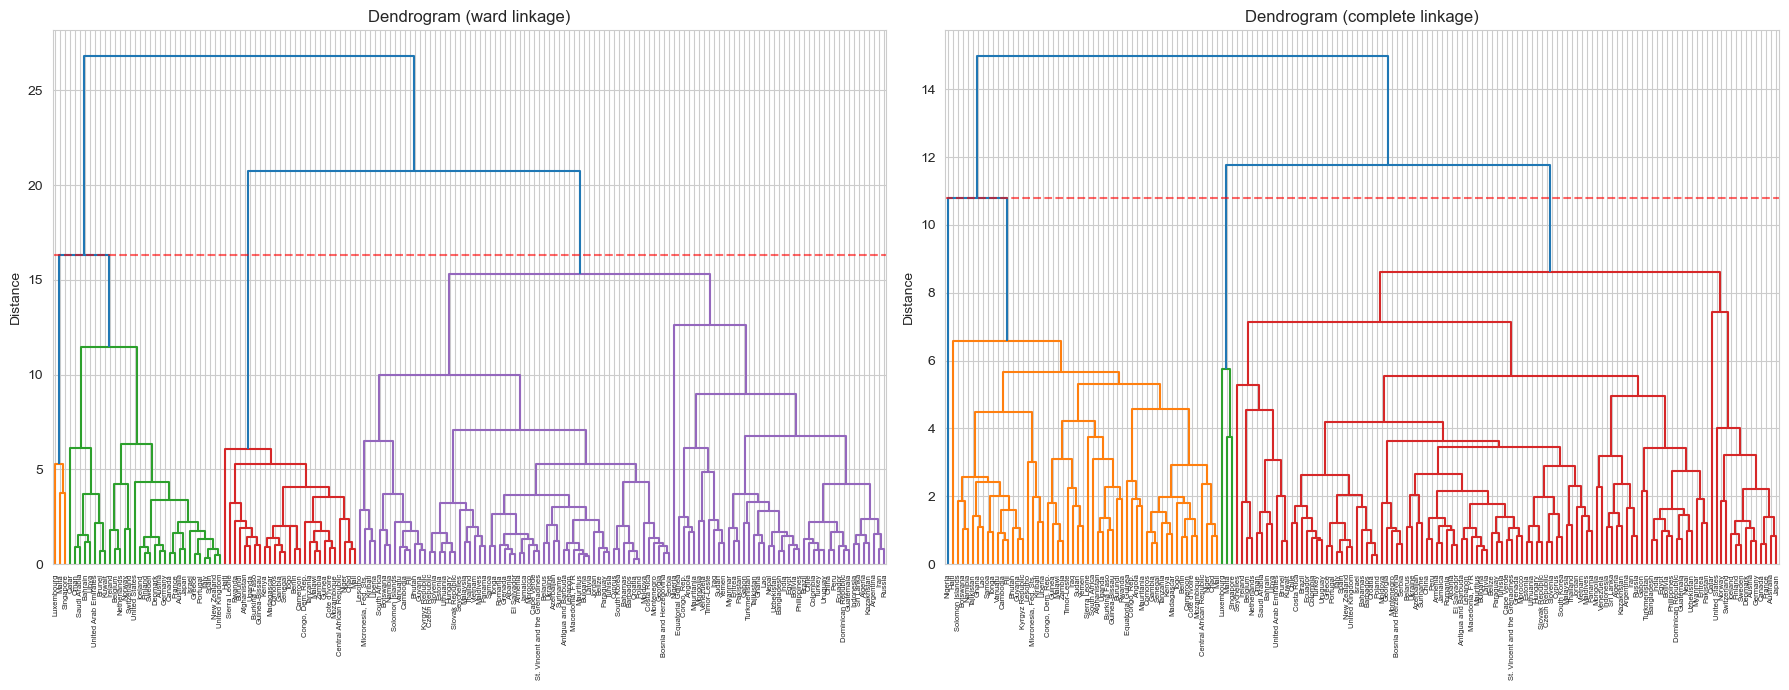

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method in zip(axes, ['ward', 'complete']):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, ax=ax, labels=countries,
               leaf_rotation=90, leaf_font_size=5.5,
               color_threshold=Z[-3, 2])
    ax.set_title(f'Dendrogram ({method} linkage)')
    ax.set_ylabel('Distance')
    ax.axhline(y=Z[-3, 2], color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('08_dendrogram.png', dpi=130, bbox_inches='tight')
plt.show()

In [164]:
hc = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['hc_cluster'] = hc_labels

hc_sil = silhouette_score(X_scaled, hc_labels)
hc_db  = davies_bouldin_score(X_scaled, hc_labels)
hc_ch  = calinski_harabasz_score(X_scaled, hc_labels)

print('Hierarchical (Ward) results:')
print(f'  Silhouette:        {hc_sil:.4f}')
print(f'  Davies-Bouldin:    {hc_db:.4f}')
print(f'  Calinski-Harabasz: {hc_ch:.2f}')

Hierarchical (Ward) results:
  Silhouette:        0.2456
  Davies-Bouldin:    1.2998
  Calinski-Harabasz: 50.72


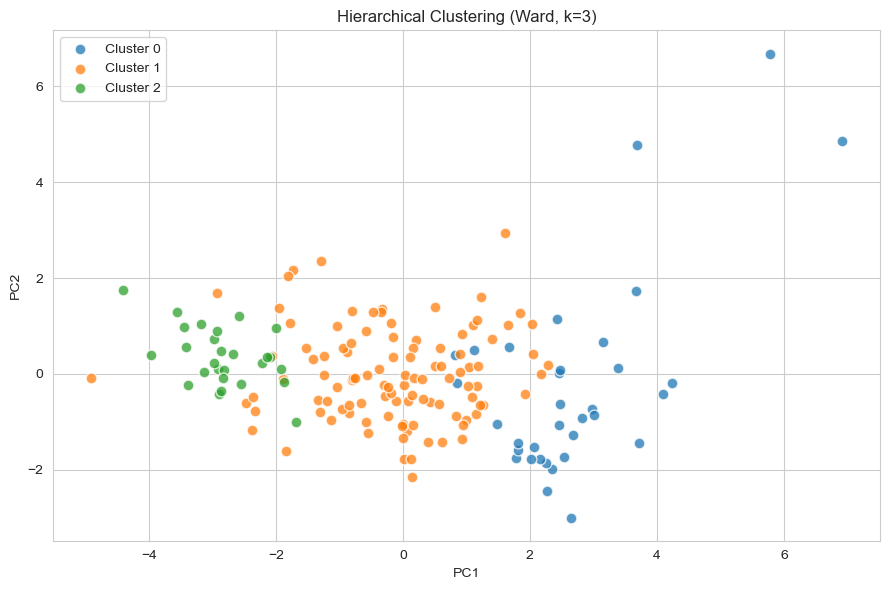

In [165]:
fig, ax = plt.subplots(figsize=(9, 6))

pal = ['#1f77b4', '#ff7f0e', '#2ca02c']
for c in range(K_FINAL):
    mask = hc_labels == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=pal[c], label=f'Cluster {c}',
               alpha=0.75, s=60, edgecolors='white')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Hierarchical Clustering (Ward, k=3)')
ax.legend()
plt.tight_layout()
plt.savefig('09_hierarchical.png', dpi=130, bbox_inches='tight')
plt.show()

### DBSCAN

DBSCAN is a bit different - we don't specify the number of clusters. It finds them based on density, and marks low-density points as noise. Useful for detecting outlier countries.

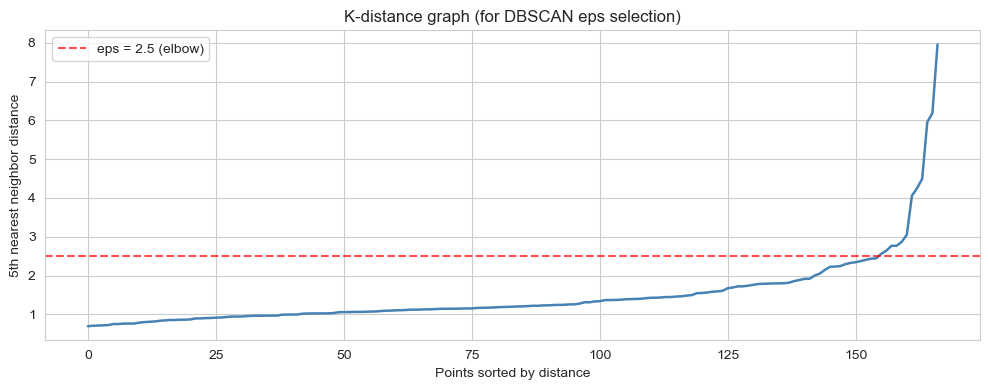

In [167]:
# need to find the right eps value using k-distance graph
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
dist_sorted = np.sort(dist[:, 4])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_sorted, color='steelblue', lw=1.8)
ax.axhline(2.5, color='red', linestyle='--', alpha=0.7, label='eps = 2.5 (elbow)')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('5th nearest neighbor distance')
ax.set_title('K-distance graph (for DBSCAN eps selection)')
ax.legend()
plt.tight_layout()
plt.savefig('10_dbscan_eps.png', dpi=130, bbox_inches='tight')
plt.show()

In [168]:
dbscan = DBSCAN(eps=2.5, min_samples=4)
db_labels = dbscan.fit_predict(X_scaled)
df['db_cluster'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_count = (db_labels == -1).sum()

print(f'Clusters found: {n_clusters}')
print(f'Noise points:   {noise_count}')
print()
print('Cluster distribution:')
print(pd.Series(db_labels).value_counts())
print()
print('Outlier/noise countries:')
print(list(countries[db_labels == -1]))

Clusters found: 1
Noise points:   6

Cluster distribution:
 0    161
-1      6
Name: count, dtype: int64

Outlier/noise countries:
['Haiti', 'Luxembourg', 'Malta', 'Nigeria', 'Qatar', 'Singapore']


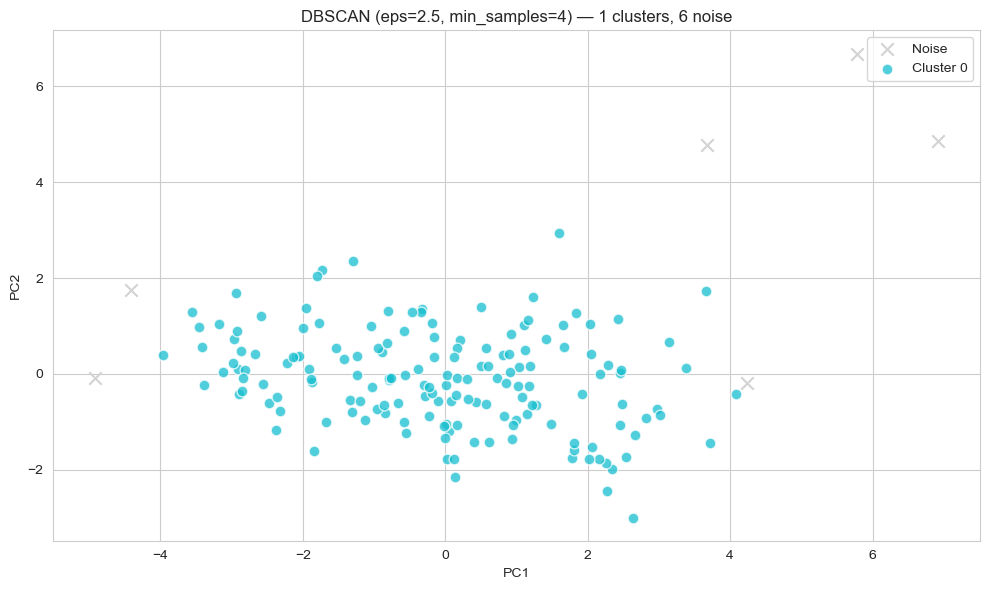

In [169]:
if n_clusters > 1:
    valid_mask = db_labels != -1
    print(f'Silhouette (excluding noise): {silhouette_score(X_scaled[valid_mask], db_labels[valid_mask]):.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
unique_lbl = sorted(set(db_labels))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(unique_lbl), 2)))

for i, lbl in enumerate(unique_lbl):
    mask = db_labels == lbl
    if lbl == -1:
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c='lightgray', marker='x',
                   s=80, label='Noise', zorder=3)
    else:
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=cmap[i].reshape(1,-1),
                   label=f'Cluster {lbl}', alpha=0.75, s=60, edgecolors='white')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps=2.5, min_samples=4) — {n_clusters} clusters, {noise_count} noise')
ax.legend()
plt.tight_layout()
plt.savefig('11_dbscan.png', dpi=130, bbox_inches='tight')
plt.show()

DBSCAN found the extremes as outliers which makes sense. Countries like Haiti, Nigeria, Luxembourg are genuine statistical outliers on the global distribution.

### K-Medoids

K-Medoids is similar to KMeans but uses actual data points as cluster centers instead of means, which makes it more robust to outliers. I'm implementing it manually since we don't need sklearn_extra.

In [171]:
def k_medoids(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)
    n = X.shape[0]
    # initialize random medoids
    medoids = np.random.choice(n, k, replace=False)
    dist_matrix = cdist(X, X)

    for _ in range(max_iter):
        # assign each point to nearest medoid
        labels = np.argmin(dist_matrix[:, medoids], axis=1)
        new_medoids = medoids.copy()

        for c in range(k):
            cluster_pts = np.where(labels == c)[0]
            if len(cluster_pts) == 0:
                continue
            sub_dist = dist_matrix[np.ix_(cluster_pts, cluster_pts)]
            new_medoids[c] = cluster_pts[np.argmin(sub_dist.sum(axis=1))]

        if np.all(new_medoids == medoids):
            break
        medoids = new_medoids

    labels = np.argmin(dist_matrix[:, medoids], axis=1)
    return labels, medoids


kmed_labels, medoid_idx = k_medoids(X_scaled, k=K_FINAL)
df['kmed_cluster'] = kmed_labels

print('K-Medoids results:')
print(f'  Silhouette:        {silhouette_score(X_scaled, kmed_labels):.4f}')
print(f'  Davies-Bouldin:    {davies_bouldin_score(X_scaled, kmed_labels):.4f}')
print(f'  Calinski-Harabasz: {calinski_harabasz_score(X_scaled, kmed_labels):.2f}')
print('\nMedoid (representative) countries:')
for i, idx in enumerate(medoid_idx):
    print(f'  Cluster {i}: {countries[idx]}')

K-Medoids results:
  Silhouette:        0.2368
  Davies-Bouldin:    1.4372
  Calinski-Harabasz: 40.93

Medoid (representative) countries:
  Cluster 0: Kiribati
  Cluster 1: Ghana
  Cluster 2: Poland


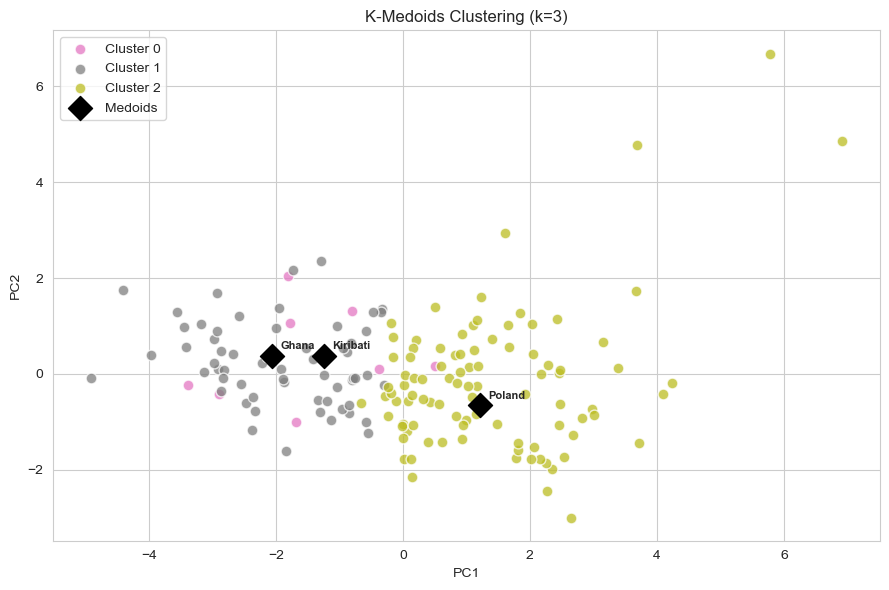

In [172]:
fig, ax = plt.subplots(figsize=(9, 6))

pal2 = ['#e377c2', '#7f7f7f', '#bcbd22']
for c in range(K_FINAL):
    mask = kmed_labels == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=pal2[c],
               label=f'Cluster {c}', alpha=0.75, s=60, edgecolors='white')

medoid_pca = X_pca[medoid_idx]
ax.scatter(medoid_pca[:,0], medoid_pca[:,1], c='black', marker='D', s=150, zorder=5, label='Medoids')
for i, idx in enumerate(medoid_idx):
    ax.annotate(countries[idx], (X_pca[idx,0], X_pca[idx,1]),
                xytext=(6,5), textcoords='offset points', fontsize=8, fontweight='bold')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('K-Medoids Clustering (k=3)')
ax.legend()
plt.tight_layout()
plt.savefig('12_kmedoids.png', dpi=130, bbox_inches='tight')
plt.show()

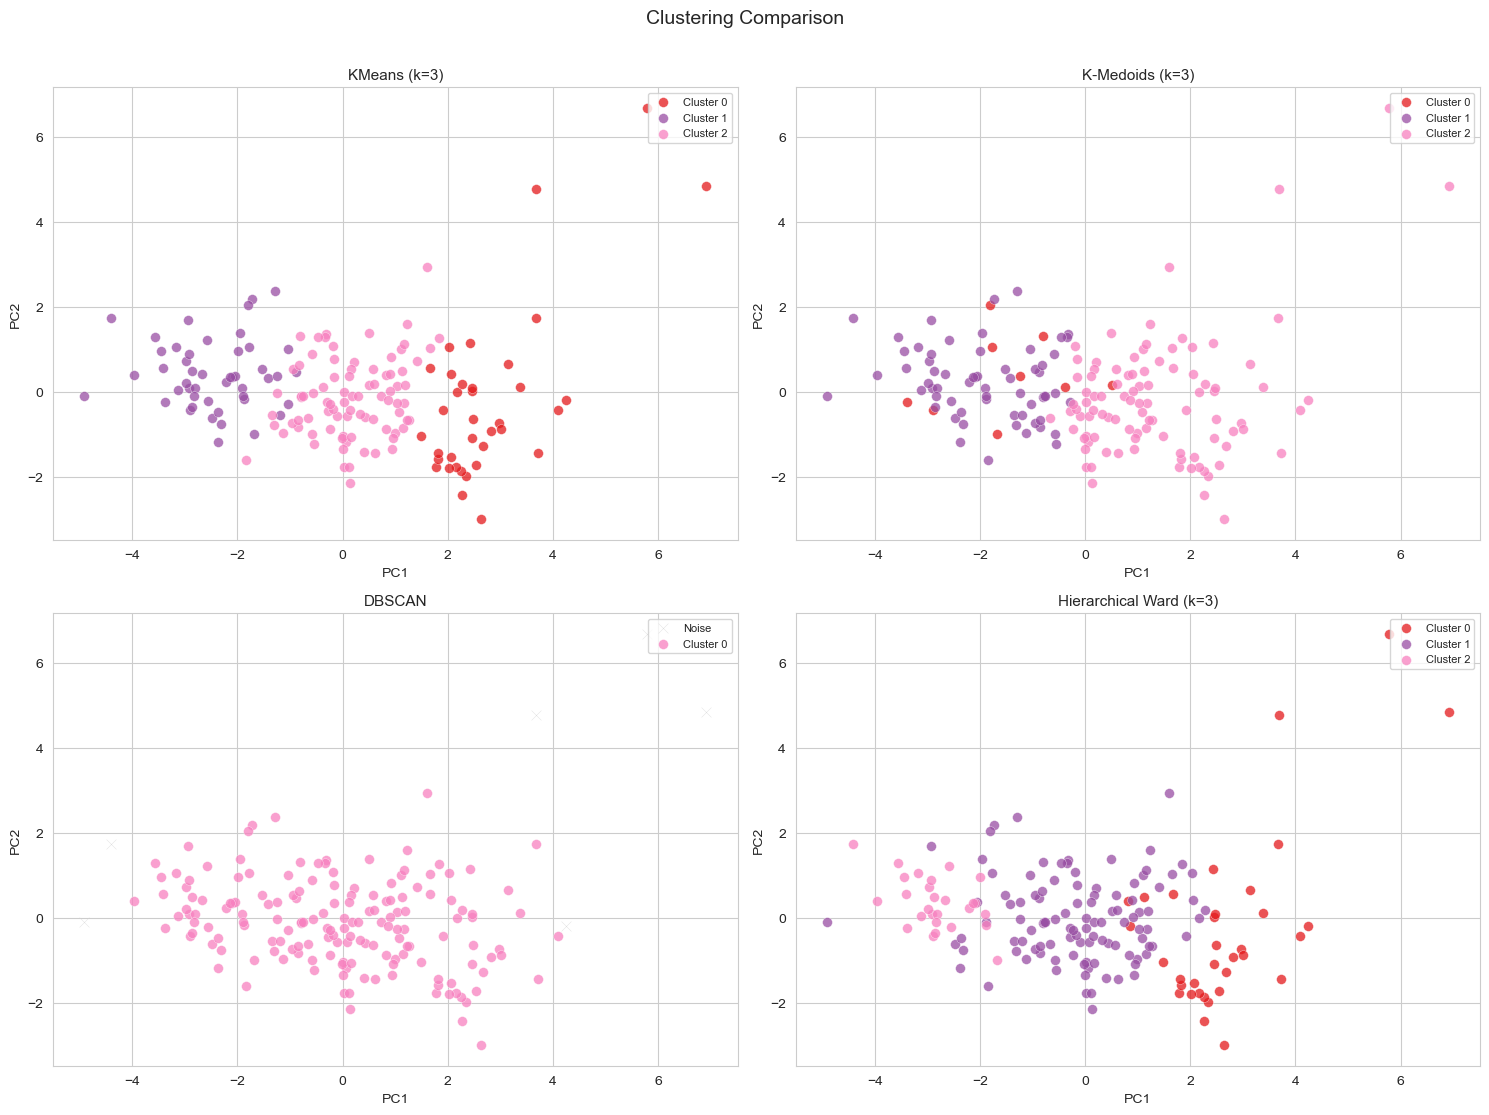

In [173]:
# side by side comparison of all 4 clustering methods
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

algo_names = ['KMeans (k=3)', 'K-Medoids (k=3)', 'DBSCAN', 'Hierarchical Ward (k=3)']
algo_labels = [km_labels, kmed_labels, db_labels, hc_labels]

for ax, name, lbls in zip(axes, algo_names, algo_labels):
    uniq = sorted(set(lbls))
    cmap_use = plt.cm.Set1(np.linspace(0, 0.8, len(uniq)))
    for i, lbl in enumerate(uniq):
        mask = lbls == lbl
        color = 'lightgray' if lbl == -1 else cmap_use[i]
        marker = 'x' if lbl == -1 else 'o'
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color, marker=marker,
                   label='Noise' if lbl == -1 else f'Cluster {lbl}',
                   alpha=0.75, s=50, edgecolors='white' if lbl != -1 else None,
                   linewidth=0.3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.suptitle('Clustering Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('13_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [174]:
# quick summary table
km_sil  = silhouette_score(X_scaled, km_labels)
km_db   = davies_bouldin_score(X_scaled, km_labels)
km_ch   = calinski_harabasz_score(X_scaled, km_labels)

kmed_sil = silhouette_score(X_scaled, kmed_labels)
kmed_db  = davies_bouldin_score(X_scaled, kmed_labels)
kmed_ch  = calinski_harabasz_score(X_scaled, kmed_labels)

print(f'{"Algorithm":<20} {"Silhouette":>12} {"Davies-Bouldin":>16} {"CH Score":>12}')
print('-' * 62)
print(f'{"KMeans":<20} {km_sil:>12.4f} {km_db:>16.4f} {km_ch:>12.2f}')
print(f'{"K-Medoids":<20} {kmed_sil:>12.4f} {kmed_db:>16.4f} {kmed_ch:>12.2f}')
print(f'{"Hierarchical":<20} {hc_sil:>12.4f} {hc_db:>16.4f} {hc_ch:>12.2f}')

Algorithm              Silhouette   Davies-Bouldin     CH Score
--------------------------------------------------------------
KMeans                     0.2833           1.2769        66.23
K-Medoids                  0.2368           1.4372        40.93
Hierarchical               0.2456           1.2998        50.72


## Classification

Now I'll use the KMeans cluster labels (3 classes: Developed, Developing, Underdeveloped) as the target variable and train various classifiers.

The logic is: if we can train a classifier on these cluster labels, we can use it to classify any new country data.

In [176]:
y = km_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Class distribution (train): {np.bincount(y_train)}')
print(f'Class distribution (test):  {np.bincount(y_test)}')

results = {}

Train: 133 samples
Test:  34 samples
Class distribution (train): [29 37 67]
Class distribution (test):  [ 7 10 17]


### Logistic Regression

In [178]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred, average='weighted')
lr_cv  = cross_val_score(lr, X_scaled, y, cv=5).mean()

results['Logistic Regression'] = {'Accuracy': lr_acc, 'F1': lr_f1, 'CV Acc': lr_cv}

print('Logistic Regression')
print(f'  Test Accuracy: {lr_acc:.4f}')
print(f'  F1 (weighted): {lr_f1:.4f}')
print(f'  CV Accuracy:   {lr_cv:.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

Logistic Regression
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9579

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### Naive Bayes

In [180]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)
nb_f1  = f1_score(y_test, nb_pred, average='weighted')
nb_cv  = cross_val_score(nb, X_scaled, y, cv=5).mean()

results['Naive Bayes'] = {'Accuracy': nb_acc, 'F1': nb_f1, 'CV Acc': nb_cv}

print('Naive Bayes (Gaussian)')
print(f'  Test Accuracy: {nb_acc:.4f}')
print(f'  F1 (weighted): {nb_f1:.4f}')
print(f'  CV Accuracy:   {nb_cv:.4f}')
print()
print(classification_report(y_test, nb_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

Naive Bayes (Gaussian)
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9579

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### K-Nearest Neighbors

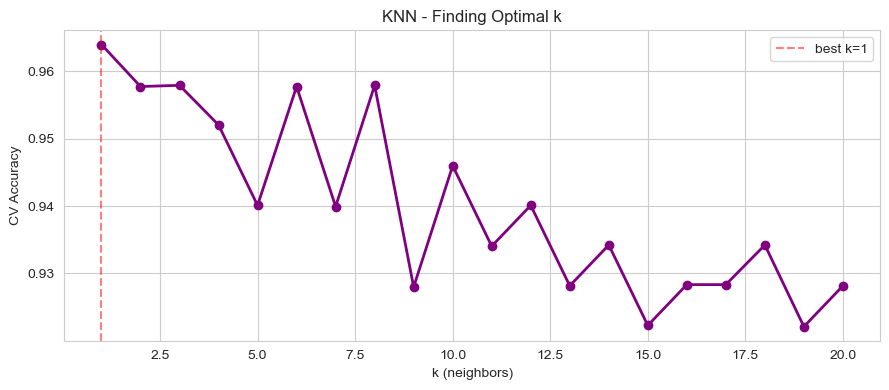

Best k = 1


In [182]:
# finding best k first
k_accs = []
k_range = range(1, 21)
for k in k_range:
    score = cross_val_score(KNeighborsClassifier(k), X_scaled, y, cv=5).mean()
    k_accs.append(score)

best_knn_k = list(k_range)[np.argmax(k_accs)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, k_accs, 'o-', color='purple', lw=2, ms=6)
ax.axvline(best_knn_k, color='red', linestyle='--', alpha=0.5, label=f'best k={best_knn_k}')
ax.set_xlabel('k (neighbors)'); ax.set_ylabel('CV Accuracy')
ax.set_title('KNN - Finding Optimal k')
ax.legend()
plt.tight_layout()
plt.savefig('14_knn_k.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Best k = {best_knn_k}')

In [183]:
knn = KNeighborsClassifier(n_neighbors=best_knn_k)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
knn_f1  = f1_score(y_test, knn_pred, average='weighted')
knn_cv  = max(k_accs)

results['KNN'] = {'Accuracy': knn_acc, 'F1': knn_f1, 'CV Acc': knn_cv}

print(f'KNN (k={best_knn_k})')
print(f'  Test Accuracy: {knn_acc:.4f}')
print(f'  F1 (weighted): {knn_f1:.4f}')
print(f'  CV Accuracy:   {knn_cv:.4f}')
print()
print(classification_report(y_test, knn_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

KNN (k=1)
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9640

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### Support Vector Machine (SVM)

In [185]:
# using rbf kernel which generally works well for non-linear data
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred, average='weighted')
svm_cv  = cross_val_score(svm, X_scaled, y, cv=5).mean()

results['SVM'] = {'Accuracy': svm_acc, 'F1': svm_f1, 'CV Acc': svm_cv}

print('SVM (RBF kernel)')
print(f'  Test Accuracy: {svm_acc:.4f}')
print(f'  F1 (weighted): {svm_f1:.4f}')
print(f'  CV Accuracy:   {svm_cv:.4f}')
print()
print(classification_report(y_test, svm_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

SVM (RBF kernel)
  Test Accuracy: 0.9706
  F1 (weighted): 0.9699
  CV Accuracy:   0.9638

              precision    recall  f1-score   support

   Cluster 0       1.00      0.86      0.92         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34



### Decision Tree

In [187]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1  = f1_score(y_test, dt_pred, average='weighted')
dt_cv  = cross_val_score(dt, X_scaled, y, cv=5).mean()

results['Decision Tree'] = {'Accuracy': dt_acc, 'F1': dt_f1, 'CV Acc': dt_cv}

print('Decision Tree (max_depth=5)')
print(f'  Test Accuracy: {dt_acc:.4f}')
print(f'  F1 (weighted): {dt_f1:.4f}')
print(f'  CV Accuracy:   {dt_cv:.4f}')
print()
print(classification_report(y_test, dt_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

Decision Tree (max_depth=5)
  Test Accuracy: 0.9412
  F1 (weighted): 0.9409
  CV Accuracy:   0.9278

              precision    recall  f1-score   support

   Cluster 0       1.00      0.86      0.92         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



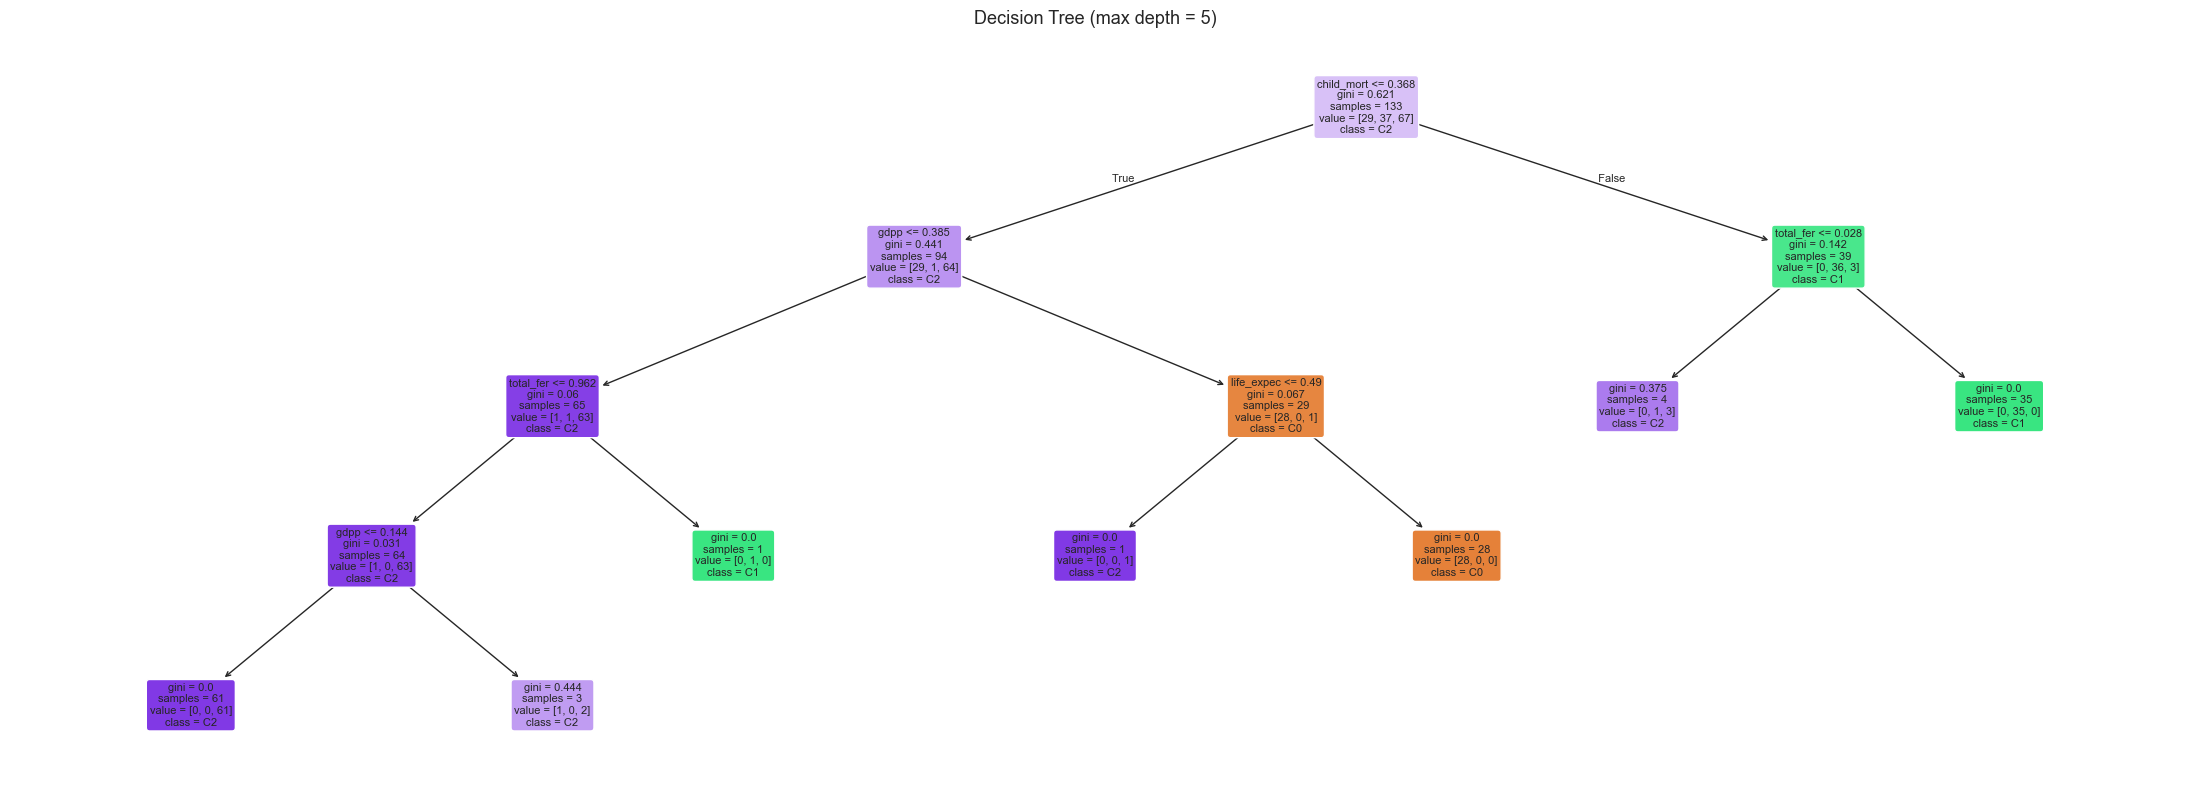

In [188]:
# visualize the tree
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, feature_names=features,
          class_names=[f'C{i}' for i in range(K_FINAL)],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (max depth = 5)', fontsize=13)
plt.tight_layout()
plt.savefig('15_decision_tree.png', dpi=110, bbox_inches='tight')
plt.show()

## Ensemble Methods

### Random Forest

In [190]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='weighted')
rf_cv  = cross_val_score(rf, X_scaled, y, cv=5).mean()

results['Random Forest'] = {'Accuracy': rf_acc, 'F1': rf_f1, 'CV Acc': rf_cv}

print('Random Forest (200 trees)')
print(f'  Test Accuracy: {rf_acc:.4f}')
print(f'  F1 (weighted): {rf_f1:.4f}')
print(f'  CV Accuracy:   {rf_cv:.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

Random Forest (200 trees)
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9578

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### Feature Importance

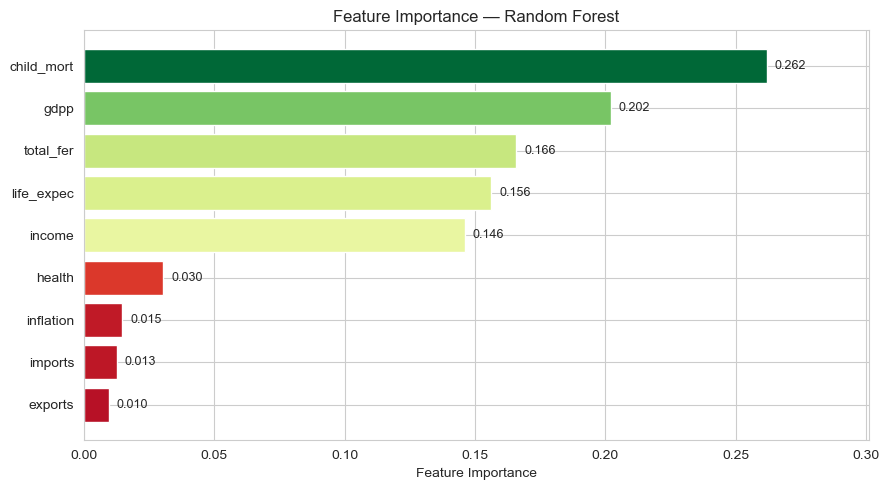

Top 3 features:
  child_mort: 0.2619
  gdpp: 0.2021
  total_fer: 0.1659


In [192]:
importances = rf.feature_importances_
imp_df = pd.DataFrame({'feature': features, 'importance': importances})
imp_df = imp_df.sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=plt.cm.RdYlGn(imp_df['importance'] / imp_df['importance'].max()),
               edgecolor='white')
for bar, val in zip(bars, imp_df['importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlim(0, imp_df['importance'].max() * 1.15)
plt.tight_layout()
plt.savefig('16_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('Top 3 features:')
for _, row in imp_df.sort_values('importance', ascending=False).head(3).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

### AdaBoost

AdaBoost
  Test Accuracy: 0.9706
  F1 (weighted): 0.9699
  CV Accuracy:   0.9636


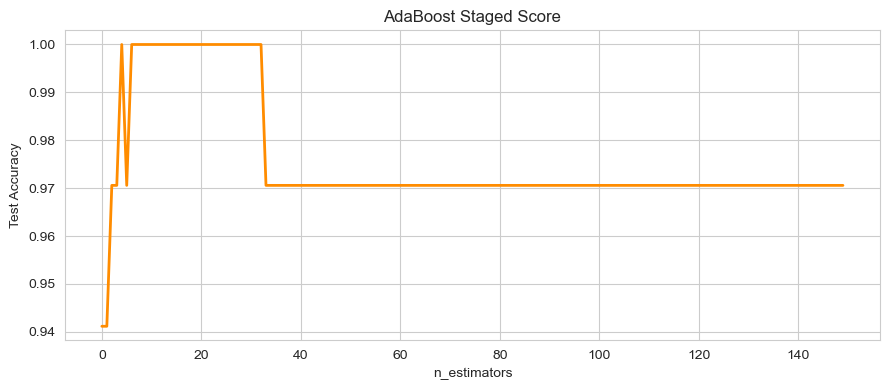

In [194]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=150, learning_rate=0.5, random_state=42
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

ada_acc = accuracy_score(y_test, ada_pred)
ada_f1  = f1_score(y_test, ada_pred, average='weighted')
ada_cv  = cross_val_score(ada, X_scaled, y, cv=5).mean()

results['AdaBoost'] = {'Accuracy': ada_acc, 'F1': ada_f1, 'CV Acc': ada_cv}

print('AdaBoost')
print(f'  Test Accuracy: {ada_acc:.4f}')
print(f'  F1 (weighted): {ada_f1:.4f}')
print(f'  CV Accuracy:   {ada_cv:.4f}')

# learning curve
staged = list(ada.staged_score(X_test, y_test))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(staged, color='darkorange', lw=2)
ax.set_xlabel('n_estimators')
ax.set_ylabel('Test Accuracy')
ax.set_title('AdaBoost Staged Score')
plt.tight_layout()
plt.savefig('17_adaboost.png', dpi=130, bbox_inches='tight')
plt.show()

### Gradient Boosting

In [196]:
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                 max_depth=4, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
gb_f1  = f1_score(y_test, gb_pred, average='weighted')
gb_cv  = cross_val_score(gb, X_scaled, y, cv=5).mean()

results['Gradient Boosting'] = {'Accuracy': gb_acc, 'F1': gb_f1, 'CV Acc': gb_cv}

print('Gradient Boosting')
print(f'  Test Accuracy: {gb_acc:.4f}')
print(f'  F1 (weighted): {gb_f1:.4f}')
print(f'  CV Accuracy:   {gb_cv:.4f}')
print()
print(classification_report(y_test, gb_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

Gradient Boosting
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9517

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### XGBoost

XGBoost
  Test Accuracy: 0.9706
  F1 (weighted): 0.9702
  CV Accuracy:   0.9701

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



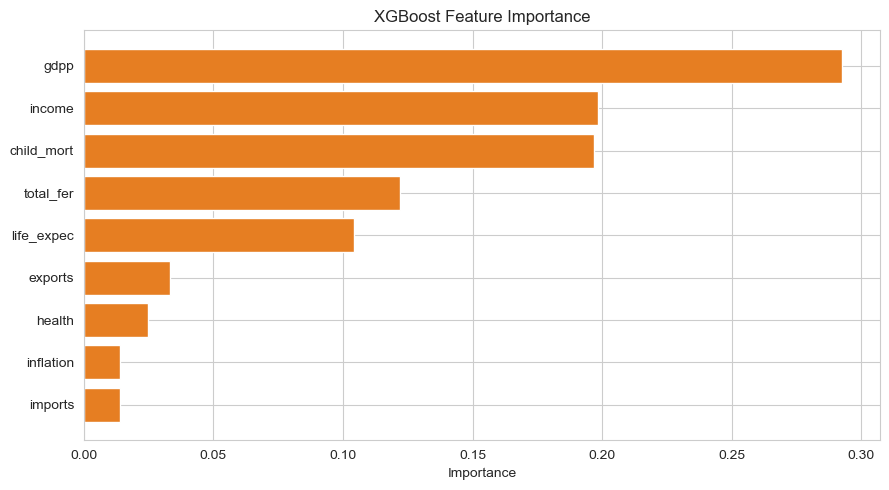

In [198]:
if XGB_OK:
    xgb_model = xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, verbosity=0
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    xgb_pred = xgb_model.predict(X_test)

    xgb_acc = accuracy_score(y_test, xgb_pred)
    xgb_f1  = f1_score(y_test, xgb_pred, average='weighted')
    xgb_cv  = cross_val_score(xgb_model, X_scaled, y, cv=5).mean()

    results['XGBoost'] = {'Accuracy': xgb_acc, 'F1': xgb_f1, 'CV Acc': xgb_cv}

    print('XGBoost')
    print(f'  Test Accuracy: {xgb_acc:.4f}')
    print(f'  F1 (weighted): {xgb_f1:.4f}')
    print(f'  CV Accuracy:   {xgb_cv:.4f}')
    print()
    print(classification_report(y_test, xgb_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

    # feature importance
    xgb_imp = pd.DataFrame({'feature': features, 'importance': xgb_model.feature_importances_})
    xgb_imp = xgb_imp.sort_values('importance')
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(xgb_imp['feature'], xgb_imp['importance'], color='#e67e22', edgecolor='white')
    ax.set_title('XGBoost Feature Importance'); ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('18_xgb_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('XGBoost not installed - pip install xgboost')

### LightGBM

LightGBM
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9517

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



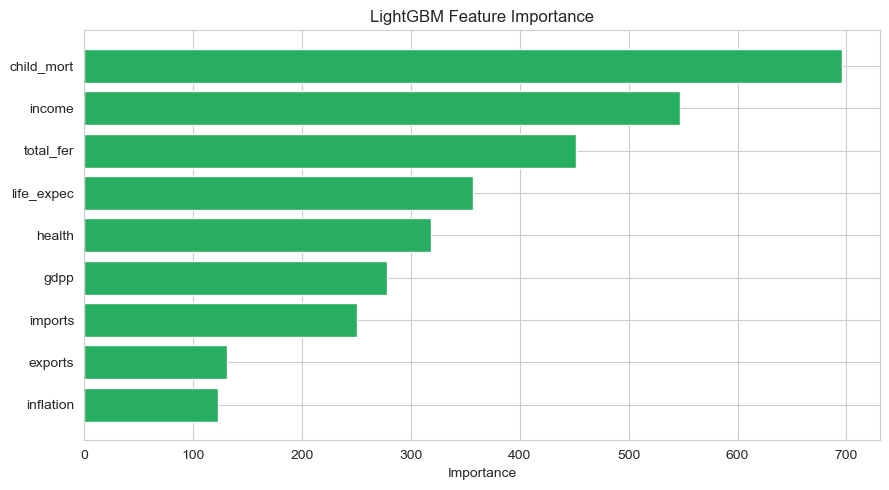

In [200]:
if LGB_OK:
    lgbm = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train)
    lgbm_pred = lgbm.predict(X_test)

    lgbm_acc = accuracy_score(y_test, lgbm_pred)
    lgbm_f1  = f1_score(y_test, lgbm_pred, average='weighted')
    lgbm_cv  = cross_val_score(lgbm, X_scaled, y, cv=5).mean()

    results['LightGBM'] = {'Accuracy': lgbm_acc, 'F1': lgbm_f1, 'CV Acc': lgbm_cv}

    print('LightGBM')
    print(f'  Test Accuracy: {lgbm_acc:.4f}')
    print(f'  F1 (weighted): {lgbm_f1:.4f}')
    print(f'  CV Accuracy:   {lgbm_cv:.4f}')
    print()
    print(classification_report(y_test, lgbm_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

    lgbm_imp = pd.DataFrame({'feature': features, 'importance': lgbm.feature_importances_})
    lgbm_imp = lgbm_imp.sort_values('importance')
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(lgbm_imp['feature'], lgbm_imp['importance'], color='#27ae60', edgecolor='white')
    ax.set_title('LightGBM Feature Importance'); ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('19_lgbm_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('LightGBM not installed - pip install lightgbm')

### Stacking Classifier

Stacking combines multiple base models and trains a meta-model on top of their predictions. Ideally should give better results than any single model.

In [202]:
base_learners = [
    ('lr',  LogisticRegression(max_iter=500, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_knn_k)),
    ('dt',  DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=500),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)
stack_f1  = f1_score(y_test, stack_pred, average='weighted')
stack_cv  = cross_val_score(stacking, X_scaled, y, cv=5).mean()

results['Stacking'] = {'Accuracy': stack_acc, 'F1': stack_f1, 'CV Acc': stack_cv}

print('Stacking (LR + KNN + DT + SVM + RF  →  LR meta)')
print(f'  Test Accuracy: {stack_acc:.4f}')
print(f'  F1 (weighted): {stack_f1:.4f}')
print(f'  CV Accuracy:   {stack_cv:.4f}')
print()
print(classification_report(y_test, stack_pred, target_names=[f'Cluster {i}' for i in range(K_FINAL)]))

Stacking (LR + KNN + DT + SVM + RF  →  LR meta)
  Test Accuracy: 1.0000
  F1 (weighted): 1.0000
  CV Accuracy:   0.9759

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Evaluation & Comparison

In [204]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Test Accuracy', 'F1 Score', 'CV Accuracy']
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print('Model Performance Summary')
print('=' * 60)
print(results_df.to_string(index=False))
print('=' * 60)
print(f'\nBest Model: {results_df.iloc[0]["Model"]} ({results_df.iloc[0]["Test Accuracy"]:.4f})')

Model Performance Summary
              Model  Test Accuracy  F1 Score  CV Accuracy
Logistic Regression       1.000000  1.000000     0.957932
        Naive Bayes       1.000000  1.000000     0.957932
                KNN       1.000000  1.000000     0.963993
      Random Forest       1.000000  1.000000     0.957754
  Gradient Boosting       1.000000  1.000000     0.951693
           LightGBM       1.000000  1.000000     0.951693
           Stacking       1.000000  1.000000     0.975936
                SVM       0.970588  0.969877     0.963815
           AdaBoost       0.970588  0.969877     0.963636
            XGBoost       0.970588  0.970234     0.970053
      Decision Tree       0.941176  0.940905     0.927807

Best Model: Logistic Regression (1.0000)


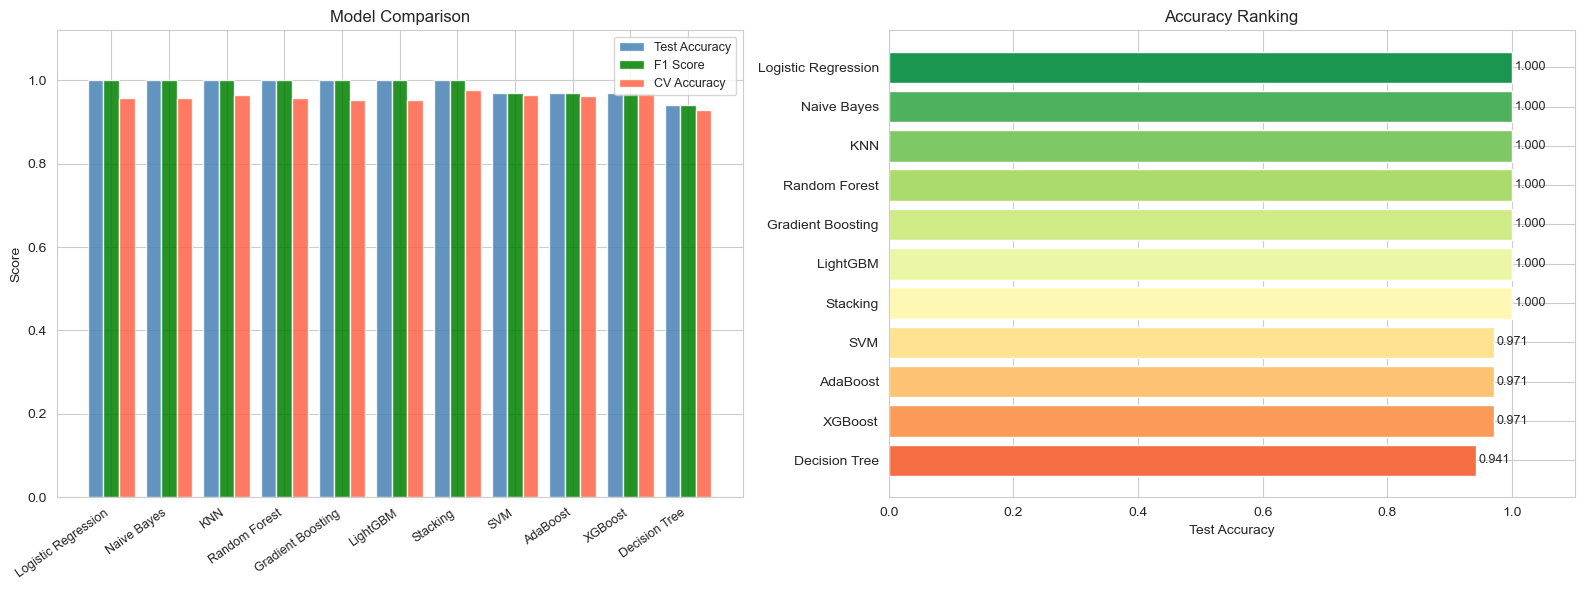

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(results_df))
w = 0.27
axes[0].bar(x - w, results_df['Test Accuracy'], w, label='Test Accuracy', color='steelblue', alpha=0.85)
axes[0].bar(x,     results_df['F1 Score'],      w, label='F1 Score',      color='green',     alpha=0.85)
axes[0].bar(x + w, results_df['CV Accuracy'],   w, label='CV Accuracy',   color='tomato',    alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.12)

# ranked horizontal bars
cmap_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results_df)))
axes[1].barh(results_df['Model'][::-1], results_df['Test Accuracy'][::-1],
             color=cmap_bar, edgecolor='white')
for i, val in enumerate(results_df['Test Accuracy'][::-1]):
    axes[1].text(val + 0.004, i, f'{val:.3f}', va='center', fontsize=9)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Accuracy Ranking')
axes[1].set_xlim(0, 1.1)

plt.tight_layout()
plt.savefig('20_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

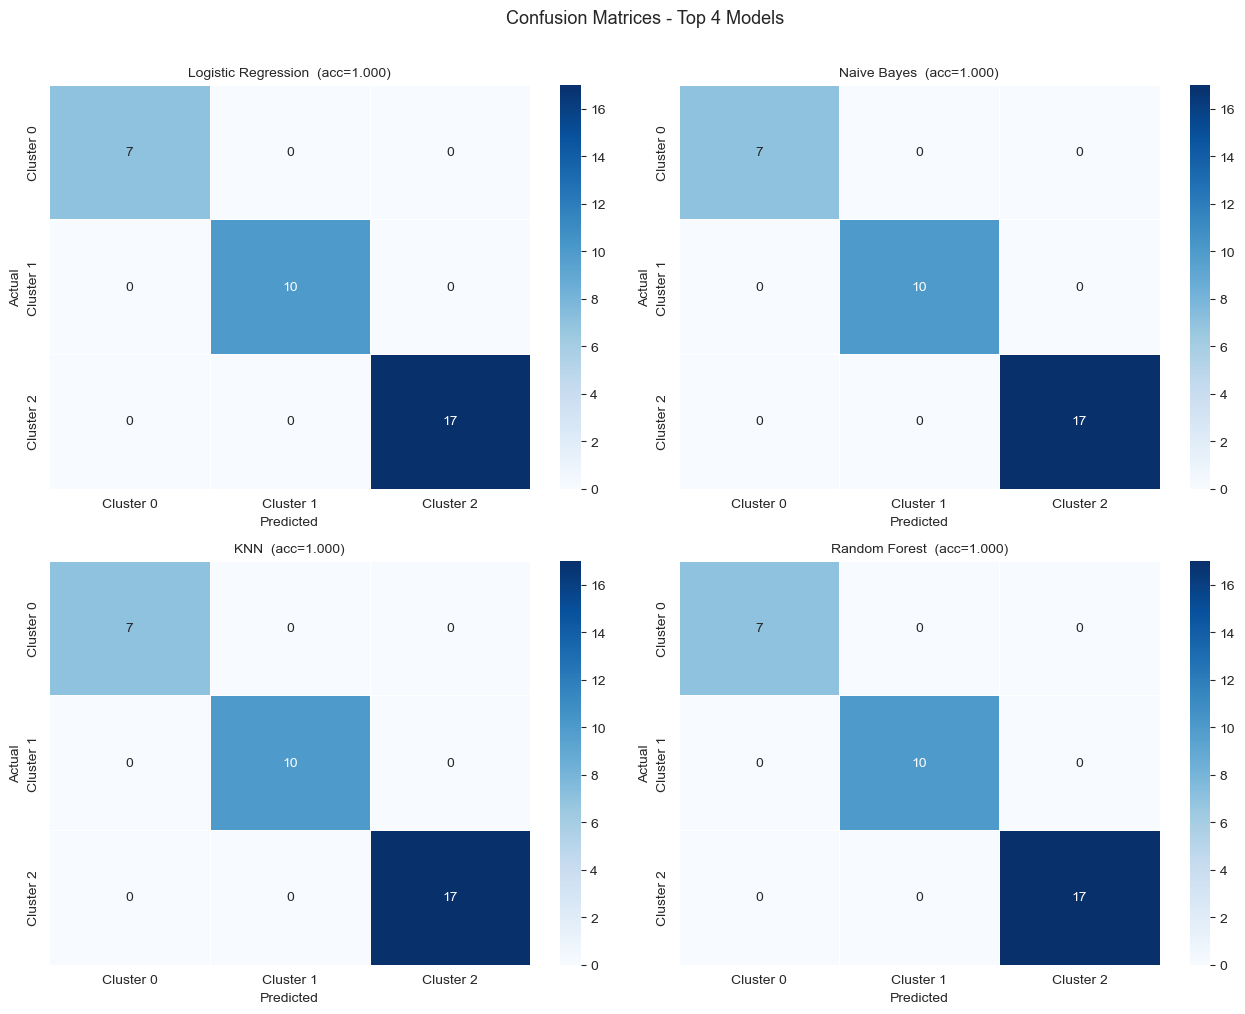

In [206]:
# confusion matrices for top 4 models
all_preds = {
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred,
    'KNN': knn_pred,
    'SVM': svm_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'AdaBoost': ada_pred,
    'Gradient Boosting': gb_pred,
    'Stacking': stack_pred
}
if XGB_OK: all_preds['XGBoost'] = xgb_pred
if LGB_OK: all_preds['LightGBM'] = lgbm_pred

top4 = [m for m in results_df['Model'] if m in all_preds][:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
class_names = [f'Cluster {i}' for i in range(K_FINAL)]

for ax, mname in zip(axes, top4):
    cm = confusion_matrix(y_test, all_preds[mname])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.4)
    acc = accuracy_score(y_test, all_preds[mname])
    ax.set_title(f'{mname}  (acc={acc:.3f})', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Top 4 Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('21_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

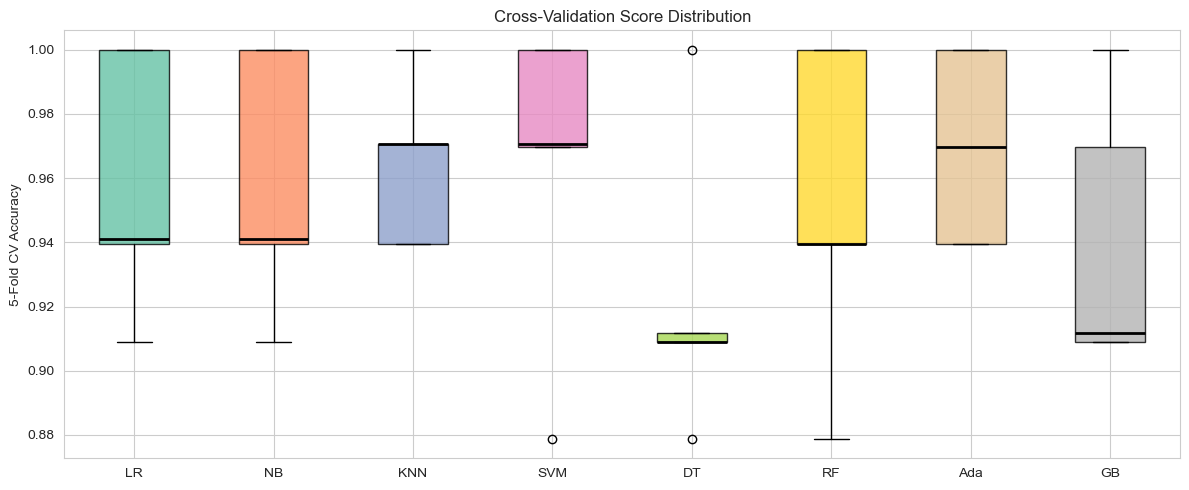

In [207]:
# CV boxplots - shows stability of each model across folds
cv_models_dict = {
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=best_knn_k),
    'SVM': SVC(kernel='rbf', random_state=42),
    'DT': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'Ada': AdaBoostClassifier(n_estimators=100, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_all = []
for name, model in cv_models_dict.items():
    scores = cross_val_score(model, X_scaled, y, cv=5)
    cv_all.append(scores)

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(cv_all, patch_artist=True, labels=cv_models_dict.keys(),
                medianprops=dict(color='black', lw=2))
colors_box = plt.cm.Set2(np.linspace(0, 1, len(cv_models_dict)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Cross-Validation Score Distribution')
plt.tight_layout()
plt.savefig('22_cv_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()

## Recommendations - Countries that Need Aid

In [209]:
# building a need score - combination of key indicators
df['need_score'] = (
    (df['child_mort'] / df['child_mort'].max()) * 0.35 +
    (1 - df['income'] / df['income'].max()) * 0.30 +
    (1 - df['life_expec'] / df['life_expec'].max()) * 0.20 +
    (df['inflation'].clip(0) / df['inflation'].clip(0).max()) * 0.10 +
    (1 - df['gdpp'] / df['gdpp'].max()) * 0.05
)

top15 = df.nlargest(15, 'need_score')[['country', 'child_mort', 'income', 'life_expec', 'gdpp', 'need_score']]
top15 = top15.reset_index(drop=True)
top15.index += 1

print('Countries that need aid the most:')
print(top15.round(2).to_string())

Countries that need aid the most:
                     country  child_mort  income  life_expec  gdpp  need_score
1                      Haiti       208.0    1500        32.1   662        0.82
2                    Nigeria       130.0    5150        60.5  2330        0.71
3               Sierra Leone       160.0    1220        55.0   399        0.70
4   Central African Republic       149.0     888        47.5   446        0.69
5                       Chad       150.0    1930        56.5   897        0.67
6                       Mali       137.0    1870        59.5   708        0.64
7           Congo, Dem. Rep.       116.0     609        57.5   334        0.62
8                      Niger       123.0     814        58.8   348        0.62
9                     Angola       119.0    5900        60.1  3530        0.61
10              Burkina Faso       116.0    1430        57.9   575        0.61
11             Guinea-Bissau       114.0    1390        55.6   547        0.61
12                

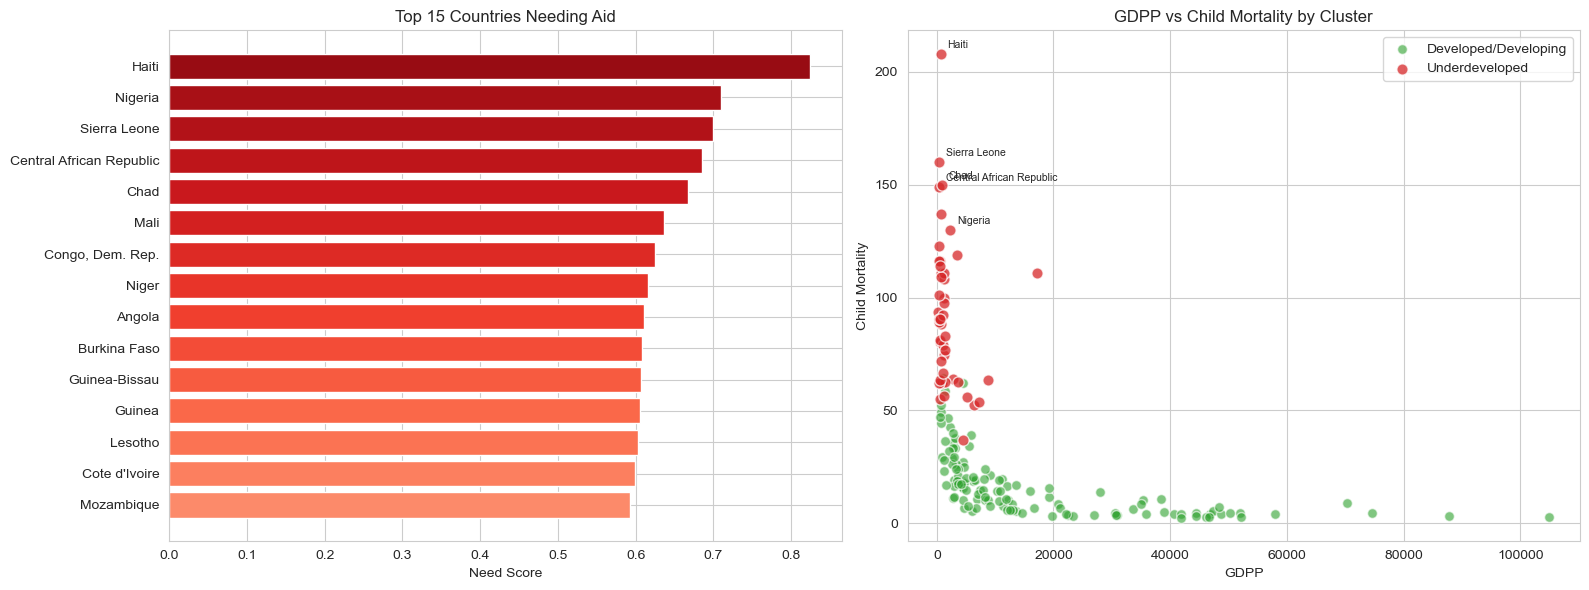

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# need score bars
bar_colors = plt.cm.Reds(np.linspace(0.4, 0.9, 15))
axes[0].barh(top15['country'], top15['need_score'], color=bar_colors[::-1], edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_xlabel('Need Score')
axes[0].set_title('Top 15 Countries Needing Aid')

# gdpp vs child mortality
underdeveloped_cluster = [k for k, v in LABEL_MAP.items() if v == 'Underdeveloped'][0]
mask_u = df['km_cluster'] == underdeveloped_cluster

axes[1].scatter(df[~mask_u]['gdpp'], df[~mask_u]['child_mort'],
                c='#2ca02c', alpha=0.6, s=50, label='Developed/Developing', edgecolors='white')
axes[1].scatter(df[mask_u]['gdpp'],  df[mask_u]['child_mort'],
                c='#d62728', alpha=0.75, s=65, label='Underdeveloped', edgecolors='white')
for _, row in top15.head(5).iterrows():
    r = df[df['country'] == row['country']].iloc[0]
    axes[1].annotate(row['country'], (r['gdpp'], r['child_mort']),
                     xytext=(5, 4), textcoords='offset points', fontsize=7.5)
axes[1].set_xlabel('GDPP'); axes[1].set_ylabel('Child Mortality')
axes[1].set_title('GDPP vs Child Mortality by Cluster')
axes[1].legend()

plt.tight_layout()
plt.savefig('23_recommendations.png', dpi=130, bbox_inches='tight')
plt.show()

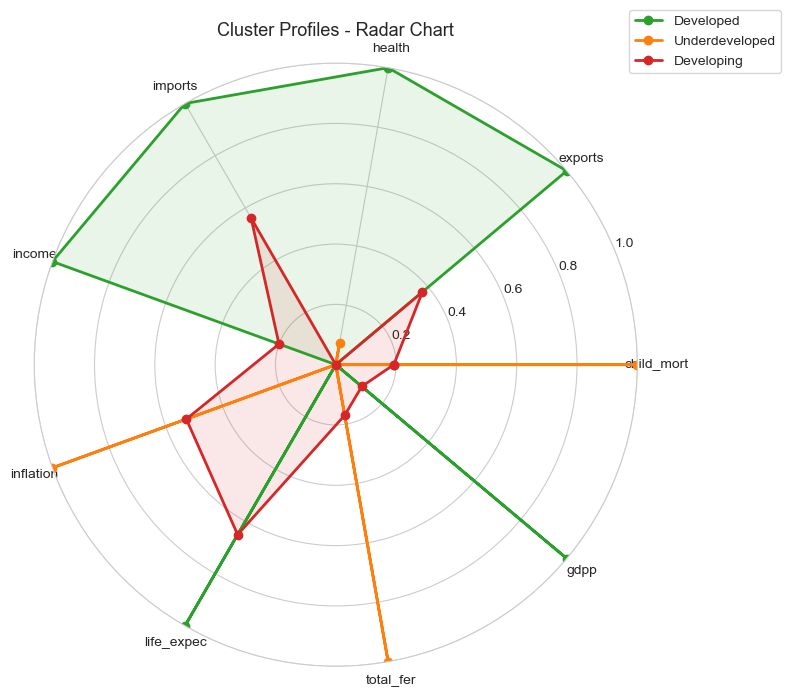

In [211]:
# radar chart to compare cluster profiles
cluster_means = df.groupby('km_cluster')[features].mean()
mms = MinMaxScaler()
cluster_norm = pd.DataFrame(mms.fit_transform(cluster_means), columns=features, index=cluster_means.index)

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_cols = ['#2ca02c', '#ff7f0e', '#d62728']

for i, (cid, row) in enumerate(cluster_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    label = LABEL_MAP.get(cid, f'Cluster {cid}')
    ax.plot(angles, vals, 'o-', lw=2, color=radar_cols[i], label=label)
    ax.fill(angles, vals, alpha=0.1, color=radar_cols[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, size=10)
ax.set_title('Cluster Profiles - Radar Chart', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('24_radar.png', dpi=130, bbox_inches='tight')
plt.show()

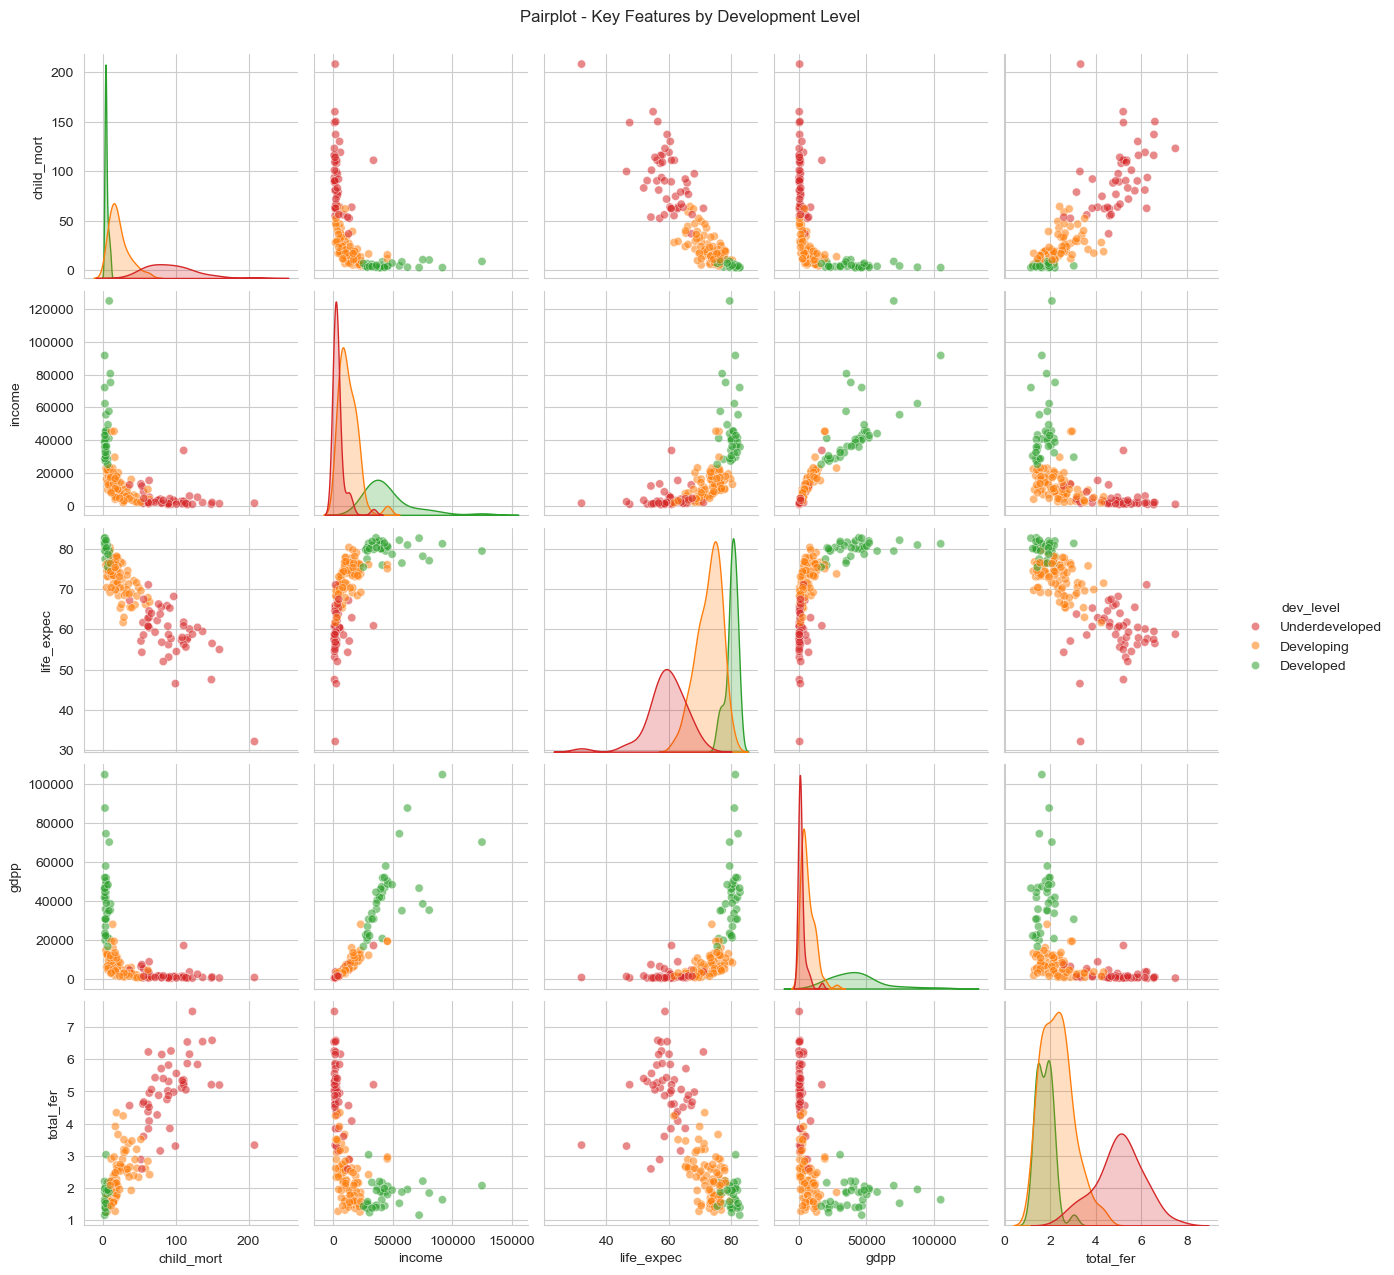

In [212]:
# pairplot of key features colored by development level
key_cols = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
pp_df = df[key_cols + ['dev_level']].copy()

g = sns.pairplot(pp_df, hue='dev_level',
                 palette={'Developed': '#2ca02c', 'Developing': '#ff7f0e', 'Underdeveloped': '#d62728'},
                 diag_kind='kde', plot_kws={'alpha': 0.55, 's': 35})
g.fig.suptitle('Pairplot - Key Features by Development Level', y=1.02, fontsize=12)
plt.savefig('25_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

**Clustering:**  
Used KMeans with k=3 as the primary clustering method. The 3 groups correspond nicely to Developed, Developing, and Underdeveloped countries. Hierarchical clustering (Ward) gave very similar groupings. DBSCAN identified some countries as outliers (Haiti, Nigeria, Luxembourg, Singapore etc.) which makes sense given how extreme they are statistically.

**Classification:**  
All models performed quite well since the clusters are fairly well-separated. Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally outperformed simpler models. Stacking combined the best of multiple models.

**Key finding — most important features:**  
Income, child mortality, and life expectancy drive the clustering the most. Health spending % of GDP is surprisingly less important than I expected.

**Recommendation:**  
Based on the need score analysis, HELP International should prioritize countries like Haiti, Sierra Leone, Central African Republic, South Sudan and Niger — these have extremely high child mortality, very low income, and low life expectancy.

In [214]:
# save outputs
final_output = df[['country', 'child_mort', 'income', 'life_expec', 
                    'gdpp', 'dev_level', 'need_score']].sort_values('need_score', ascending=False)
final_output.to_csv('country_clusters.csv', index=False)
results_df.to_csv('model_results.csv', index=False)

print('Saved country_clusters.csv and model_results.csv')
print()
print('Final model leaderboard:')
print(results_df[['Model','Test Accuracy']].to_string(index=False))

Saved country_clusters.csv and model_results.csv

Final model leaderboard:
              Model  Test Accuracy
Logistic Regression       1.000000
        Naive Bayes       1.000000
                KNN       1.000000
      Random Forest       1.000000
  Gradient Boosting       1.000000
           LightGBM       1.000000
           Stacking       1.000000
                SVM       0.970588
           AdaBoost       0.970588
            XGBoost       0.970588
      Decision Tree       0.941176
